# Analysis of the ALADIN results

In [259]:
import os
from pathlib import Path

p = Path(__file__).resolve() if "__file__" in globals() else Path.cwd()

while not (p / "ALADIN").exists():   # or any marker file
    if p.parent == p:
        raise RuntimeError("Project root not found")
    p = p.parent
os.chdir(os.path.join(p, "ALADIN"))
print("CWD set to project root:", p)

CWD set to project root: /workspaces


In [260]:
import glob
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.patches import Patch


In [261]:
BYTES_PER_KB = 1024.0
SAVE_FIGURES = False

LABEL_FONT_SIZE = 28
TICK_FONT_SIZE = 20
X_TICK_FONT_SIZE = 20
LEGEND_FONT_SIZE = 16

plt.rcParams.update({
    "font.family": "serif",
    "font.size": TICK_FONT_SIZE,
    "axes.labelsize": LABEL_FONT_SIZE,
    "xtick.labelsize": X_TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 1.2,
    "hatch.linewidth": 1.5,
})

CASE_COLORS = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
]

model_alias = {
    "mobilenet_v1": "MobileNetV1",
    "vgg": "VGG",
    "resnt": "ResNet",
    "efficientnet": "EfficientNet",
    "shufflenet": "ShuffleNet"
}

## Implementation-aware analysis

In [262]:

model_name = "efficientnet"
pattern = f"./output/STEP1_{model_name}_*.csv"

FIGURE_SIZE = (15, 10)


# ================================================================
# Implementation styles
# ================================================================
IMPLEMENTATION_STYLES = {
    "default": {
        "hatch": "",
        "label": "Default",
    },
    "lut": {
        "hatch": "/",          # instead of "///"
        "label": "LUT",
    },
    "thresholds": {
        "hatch": "\/",          # instead of "xxx"
        "label": "Thresholds",
    },
    "lut+thresholds": {
        "hatch": "xx",         # instead of "///xxx"
        "label": "LUT + Thresholds",
    },
}


### plot setup

In [ ]:


files = sorted(glob.glob(pattern))

if not files:
    raise FileNotFoundError(
        f"No CSV files match:\n{pattern}"
    )

required_columns = [
    "Op.",
    "MACs",
    "Memory",
    "BOPs",
    "implementation",
]

filename_prefix = f"STEP1_{model_name}_"

configs = []
dataframes = []

for filepath in files:
    filename = os.path.basename(filepath)
    stem = os.path.splitext(filename)[0]

    if stem.startswith(filename_prefix):
        config_name = stem[len(filename_prefix):]
    else:
        config_name = stem


    config_name = config_name.replace("case", "case ").strip()
    df = pd.read_csv(filepath)

    df.columns = df.columns.astype(str).str.strip()

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{filepath} is missing columns: {missing_columns}\n"
            f"Available columns: {df.columns.tolist()}"
        )

    df = df.copy()
    df["Op."] = df["Op."].astype(str).str.strip()

    df["implementation"] = (
        df["implementation"]
        .fillna("default")
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "threshold": "thresholds",
            "thresh": "thresholds",
            "lookup table": "lut",
            "lookup_table": "lut",
            "none": "default",
            "nan": "default",
            "": "default",
        })
    )

    for metric in ["MACs", "Memory", "BOPs"]:
        df[metric] = pd.to_numeric(df[metric], errors="coerce")

    invalid_rows = df[df[["MACs", "Memory", "BOPs"]].isna().any(axis=1)]

    if not invalid_rows.empty:
        raise ValueError(
            f"Invalid numeric values in:\n{filepath}\n\n"
            f"{invalid_rows}"
        )

    valid_implementations = {
        "default",
        "lut",
        "thresholds",
    }

    unknown_implementations = sorted(
        set(df["implementation"].unique()) - valid_implementations
    )

    if unknown_implementations:
        raise ValueError(
            f"Unknown implementation values in:\n{filepath}\n"
            f"{unknown_implementations}"
        )

    configs.append(config_name)
    dataframes.append(df)



In [ ]:
reference_operations = dataframes[0]["Op."].tolist()

for filepath, df in zip(files[1:], dataframes[1:]):
    if df["Op."].tolist() != reference_operations:
        raise ValueError(
            f"Layer names or order in:\n{filepath}\n"
            "do not match the first CSV file."
        )


num_configs = len(configs)

if num_configs > len(CASE_COLORS):
    raise ValueError(
        f"The palette supports {len(CASE_COLORS)} cases, "
        f"but {num_configs} files were found."
    )

colors = CASE_COLORS[:num_configs]

In [ ]:

def operation_type(operation_name):
    return operation_name.split("_", 1)[0].strip().lower()


block_start_types = {
    "conv",
    "gemm",
    "maxpool",
}

block_ids = []
current_block = -1

for operation_name in reference_operations:
    op_type = operation_type(operation_name)

    if op_type in block_start_types:
        current_block += 1

    if current_block < 0:
        current_block = 0

    block_ids.append(current_block)

block_ids = np.asarray(block_ids, dtype=int)
num_blocks = int(block_ids.max()) + 1
block_labels = []

for block_id in range(num_blocks):
    indices = np.flatnonzero(block_ids == block_id)
    first_operation = reference_operations[indices[0]]
    block_labels.append(first_operation)

block_labels = np.asarray(block_labels, dtype=str)


def classify_block_implementation(values):
    implementations = set(values)
    implementations.discard("default")
    contains_lut = "lut" in implementations
    contains_thresholds = "thresholds" in implementations

    if contains_lut and contains_thresholds:
        return "lut+thresholds"

    if contains_lut:
        return "lut"

    if contains_thresholds:
        return "thresholds"

    return "default"


aggregated_dataframes = []

for df in dataframes:
    working_df = df.copy()
    working_df["block_id"] = block_ids

    metric_summary = working_df.groupby(
        "block_id",
        sort=False
    )[["MACs", "Memory", "BOPs"]].sum()
    

    implementation_summary = working_df.groupby(
        "block_id",
        sort=False
    )["implementation"].apply(classify_block_implementation)

    aggregated_df = metric_summary.copy()
    aggregated_df["implementation"] = implementation_summary
    aggregated_df["Block"] = block_labels
    aggregated_dataframes.append(aggregated_df.reset_index(drop=True))



In [ ]:

mac_values = np.vstack([
    df["MACs"].to_numpy(dtype=float)
    for df in aggregated_dataframes
])

memory_values_kb = np.vstack([
    df["Memory"].to_numpy(dtype=float) / BYTES_PER_KB
    for df in aggregated_dataframes
])

bops_values = np.vstack([
    df["BOPs"].to_numpy(dtype=float)
    for df in aggregated_dataframes
])

block_implementations = np.vstack([
    df["implementation"].to_numpy(dtype=str)
    for df in aggregated_dataframes
])

nonzero_mac_mask = np.any(mac_values > 0, axis=0)

mac_plot_values = mac_values[:, nonzero_mac_mask]

mac_plot_labels = block_labels[nonzero_mac_mask]

mac_plot_implementations = block_implementations[:, nonzero_mac_mask]

total_group_width = 0.88
bar_slot_width = total_group_width / num_configs
visible_bar_width = bar_slot_width * 0.94


def grouped_positions(number_of_blocks, case_index):
    x = np.arange(number_of_blocks)
    offset = (case_index - (num_configs - 1) / 2) * bar_slot_width
    return x + offset


def draw_block_bars(ax, values, implementations):
    number_of_blocks = values.shape[1]

    for case_index in range(num_configs):
        positions = grouped_positions(number_of_blocks, case_index)

        for block_index in range(number_of_blocks):
            value = values[case_index, block_index]

            if not np.isfinite(value) or value <= 0:
                continue

            implementation = implementations[case_index, block_index]
            style = IMPLEMENTATION_STYLES[implementation]

            ax.bar(
                positions[block_index],
                value,
                width=visible_bar_width,
                color=colors[case_index],
                edgecolor="black",
                linewidth=0.8,
                hatch=style["hatch"],
                alpha=0.95,
                zorder=3
            )


In [ ]:
case_legend_handles = [
    Patch(
        facecolor=colors[index],
        edgecolor="black",
        linewidth=0.8,
        label=configs[index]
    )
    for index in range(num_configs)
]

implementations_present = set(block_implementations.ravel())

implementation_order = [
    "default",
    "lut",
    "thresholds",
    "lut+thresholds",
]

implementation_legend_handles = [
    Patch(
        facecolor="white",
        edgecolor="black",
        linewidth=1.0,
        hatch=IMPLEMENTATION_STYLES[name]["hatch"],
        label=IMPLEMENTATION_STYLES[name]["label"]
    )
    for name in implementation_order
    if name in implementations_present
]


def add_combined_legend(ax):

    section_case = Patch(
        facecolor="none",
        edgecolor="none",
        label="Case"
    )

    section_implementation = Patch(
        facecolor="none",
        edgecolor="none",
        label="Implementation"
    )

    handles = (
        [section_case]
        + case_legend_handles
        + [section_implementation]
        + implementation_legend_handles
    )

    legend = ax.legend(
        handles=handles,
        loc="upper left",
        bbox_to_anchor=(0.015, 0.985),
        borderaxespad=0.0,
        frameon=True,
        framealpha=0.94,
        facecolor="white",
        edgecolor="0.65",
        fontsize=LEGEND_FONT_SIZE,
        ncol=1,
        handlelength=1.8,
        handletextpad=0.7,
        labelspacing=0.45
    )

    for text in legend.get_texts():
        if text.get_text() in {
            "Case",
            "Implementation",
        }:
            text.set_weight("bold")

def format_axis(
    ax,
    labels,
    ylabel,
    logarithmic=False,
):
    x = np.arange(len(labels))

    ax.set_xlabel(
        "Computational block",
        fontsize=LABEL_FONT_SIZE,
        labelpad=14
    )

    ax.set_ylabel(
        ylabel,
        fontsize=LABEL_FONT_SIZE,
        labelpad=14
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right",
        fontsize=X_TICK_FONT_SIZE
    )

    ax.tick_params(
        axis="x",
        labelsize=X_TICK_FONT_SIZE,
        width=1.1,
        length=5
    )

    ax.tick_params(
        axis="y",
        labelsize=TICK_FONT_SIZE,
        width=1.1,
        length=6
    )

    if logarithmic:
        ax.set_yscale("log")

        ax.grid(
            axis="y",
            which="major",
            linestyle="--",
            linewidth=0.8,
            alpha=0.40,
            zorder=0
        )

        ax.grid(
            axis="y",
            which="minor",
            linestyle=":",
            linewidth=0.5,
            alpha=0.22,
            zorder=0
        )

    else:
        ax.grid(
            axis="y",
            which="major",
            linestyle="--",
            linewidth=0.8,
            alpha=0.35,
            zorder=0
        )

    ax.set_axisbelow(True)



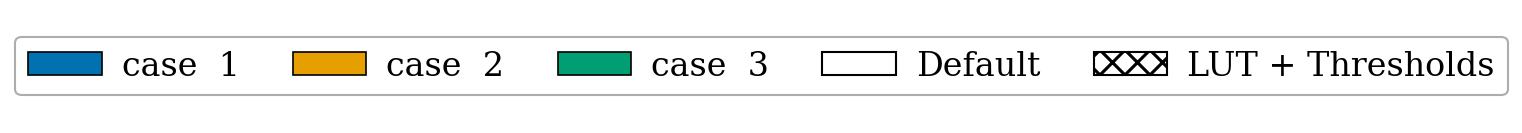

In [ ]:
case_legend_handles = [
    Patch(
        facecolor=colors[index],
        edgecolor="black",
        linewidth=0.8,
        label=configs[index]
    )
    for index in range(num_configs)
]

implementation_legend_handles = [
    Patch(
        facecolor="white",
        edgecolor="black",
        linewidth=1.0,
        hatch=IMPLEMENTATION_STYLES[name]["hatch"],
        label=IMPLEMENTATION_STYLES[name]["label"]
    )
    for name in implementation_order
    if name in implementations_present
]

handles = case_legend_handles + implementation_legend_handles

labels = (
    [h.get_label() for h in case_legend_handles] +
    [h.get_label() for h in implementation_legend_handles]
)


fig = plt.figure(figsize=(9, 0.9))
ax = fig.add_subplot(111)
ax.axis("off")

legend = ax.legend(
    handles,
    labels,
    loc="center",
    ncol=len(handles),        # all entries on one row
    frameon=True,
    fontsize=16,
    columnspacing=1.6,
    handlelength=2.2,
    handletextpad=0.6,
    edgecolor="0.6",
)

plt.show()
plt.close(fig)

### MACs:

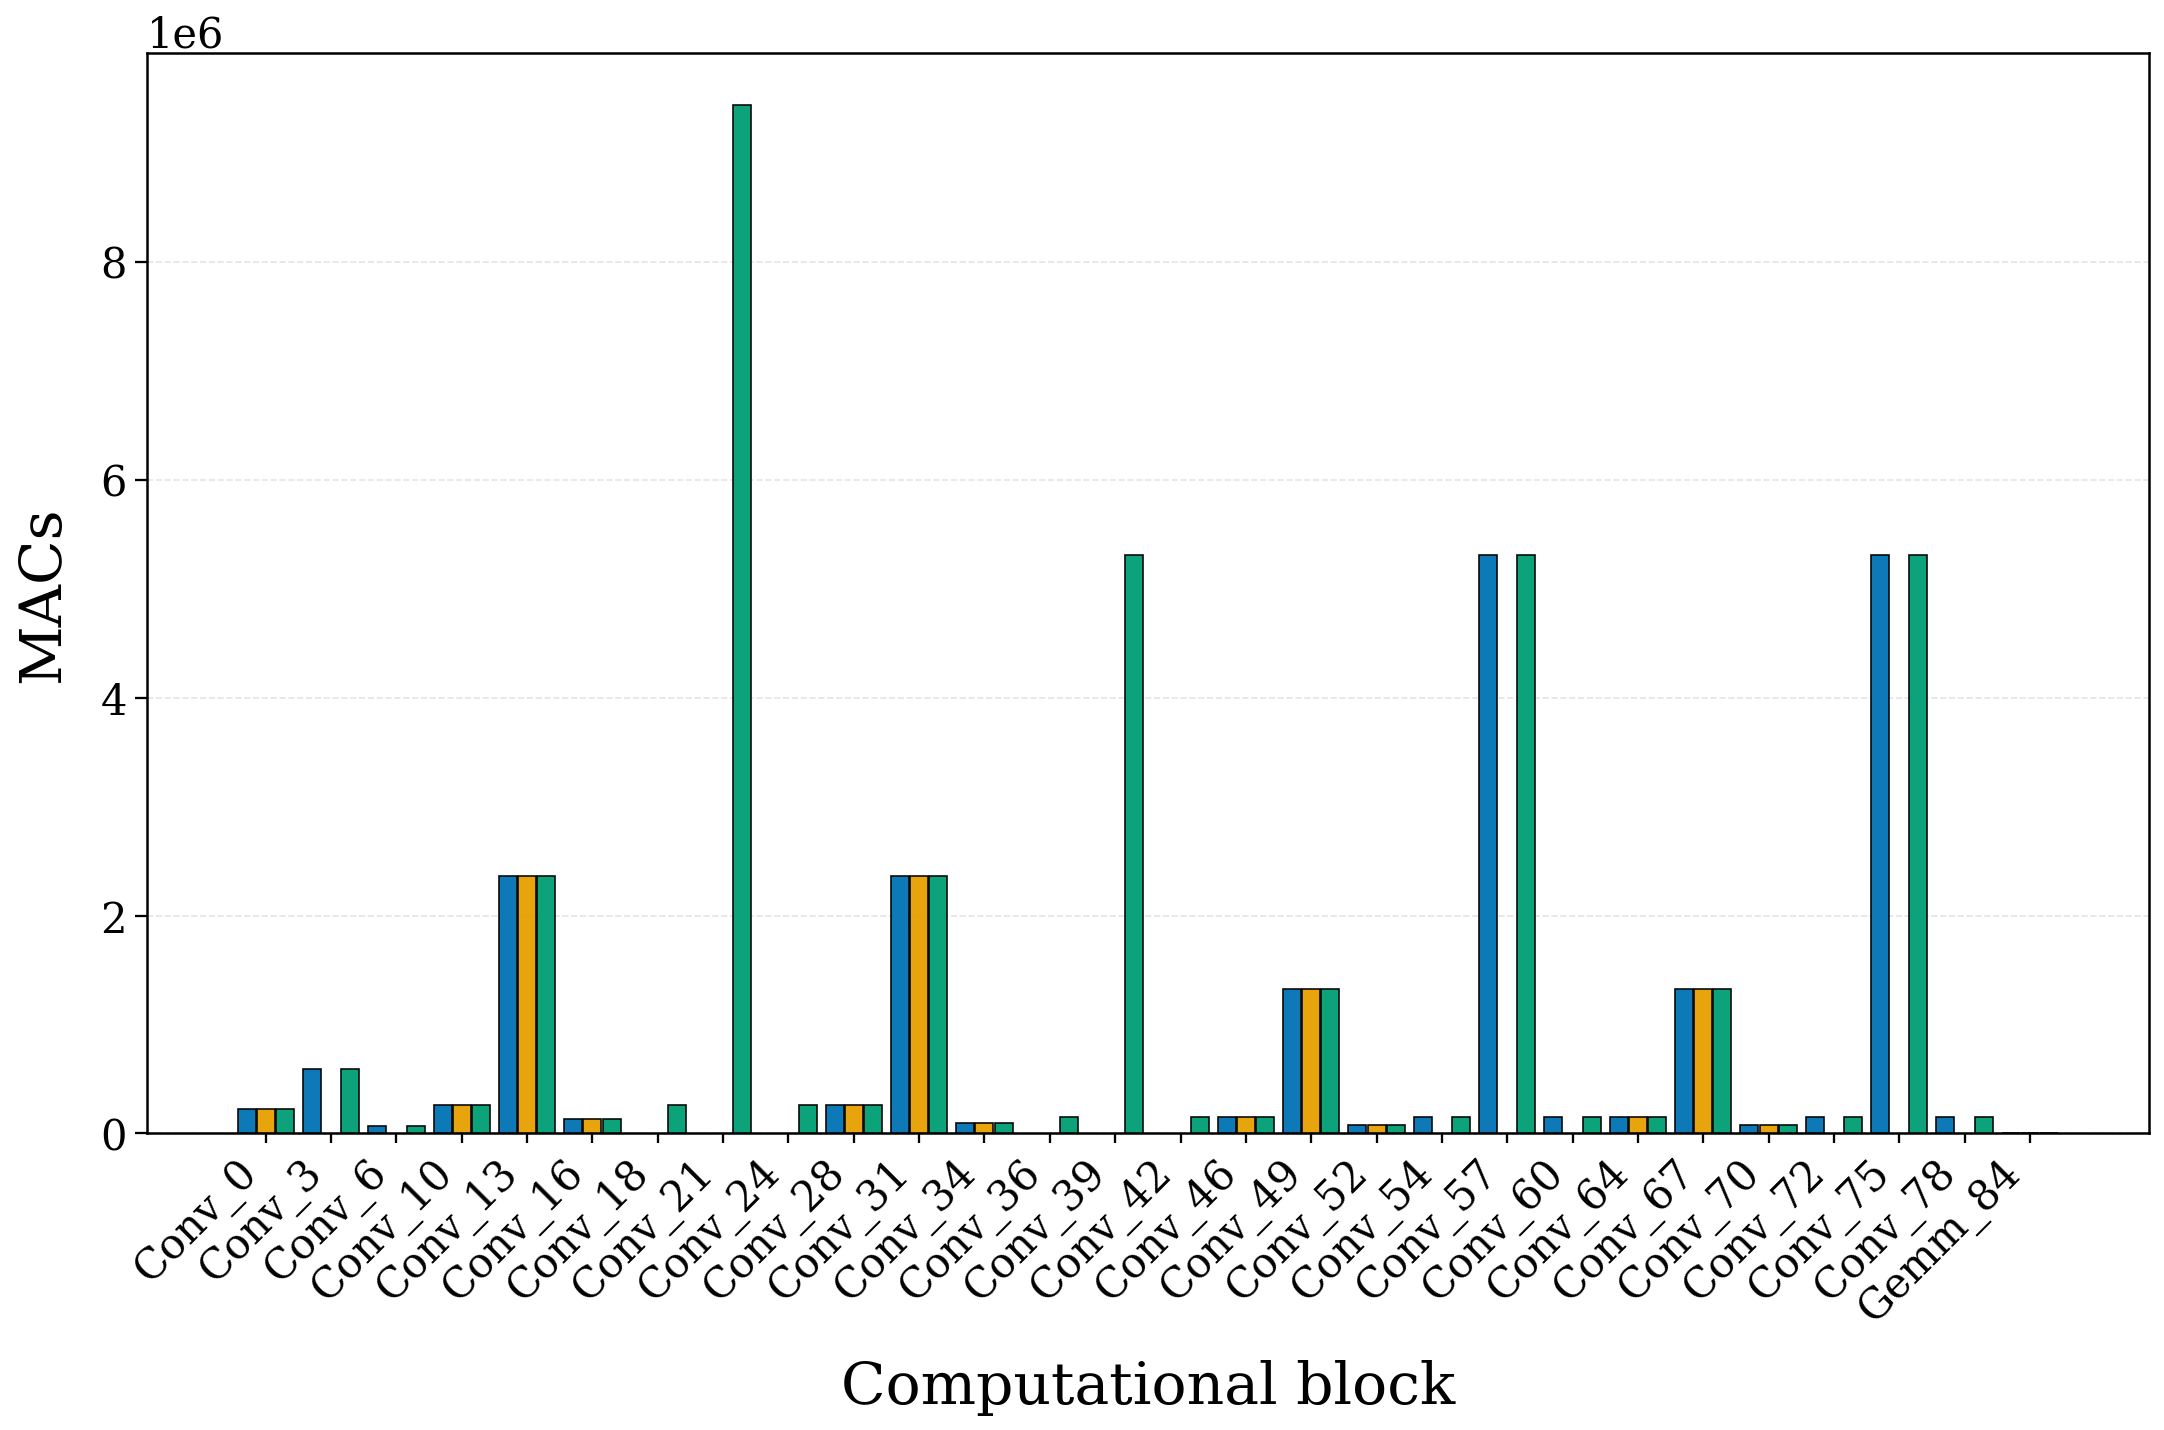

In [ ]:

# fig, ax = plt.subplots(figsize=FIGURE_SIZE)

# draw_block_bars(
#     ax=ax,
#     values=mac_plot_values,
#     implementations=mac_plot_implementations
# )

# format_axis(
#     ax=ax,
#     labels=mac_plot_labels,
#     ylabel="MACs",
#     logarithmic=False
# )

# ax.ticklabel_format(
#     axis="y",
#     style="sci",
#     scilimits=(0, 0)
# )

# # add_combined_legend(ax)

# fig.subplots_adjust(
#     left=0.09,
#     right=0.98,
#     top=0.97,
#     bottom=0.25
# )

# plt.savefig(
#     f"./output/images/{model_name}-mac.pdf",
#     format="pdf",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()
# plt.close(fig)

### Memory

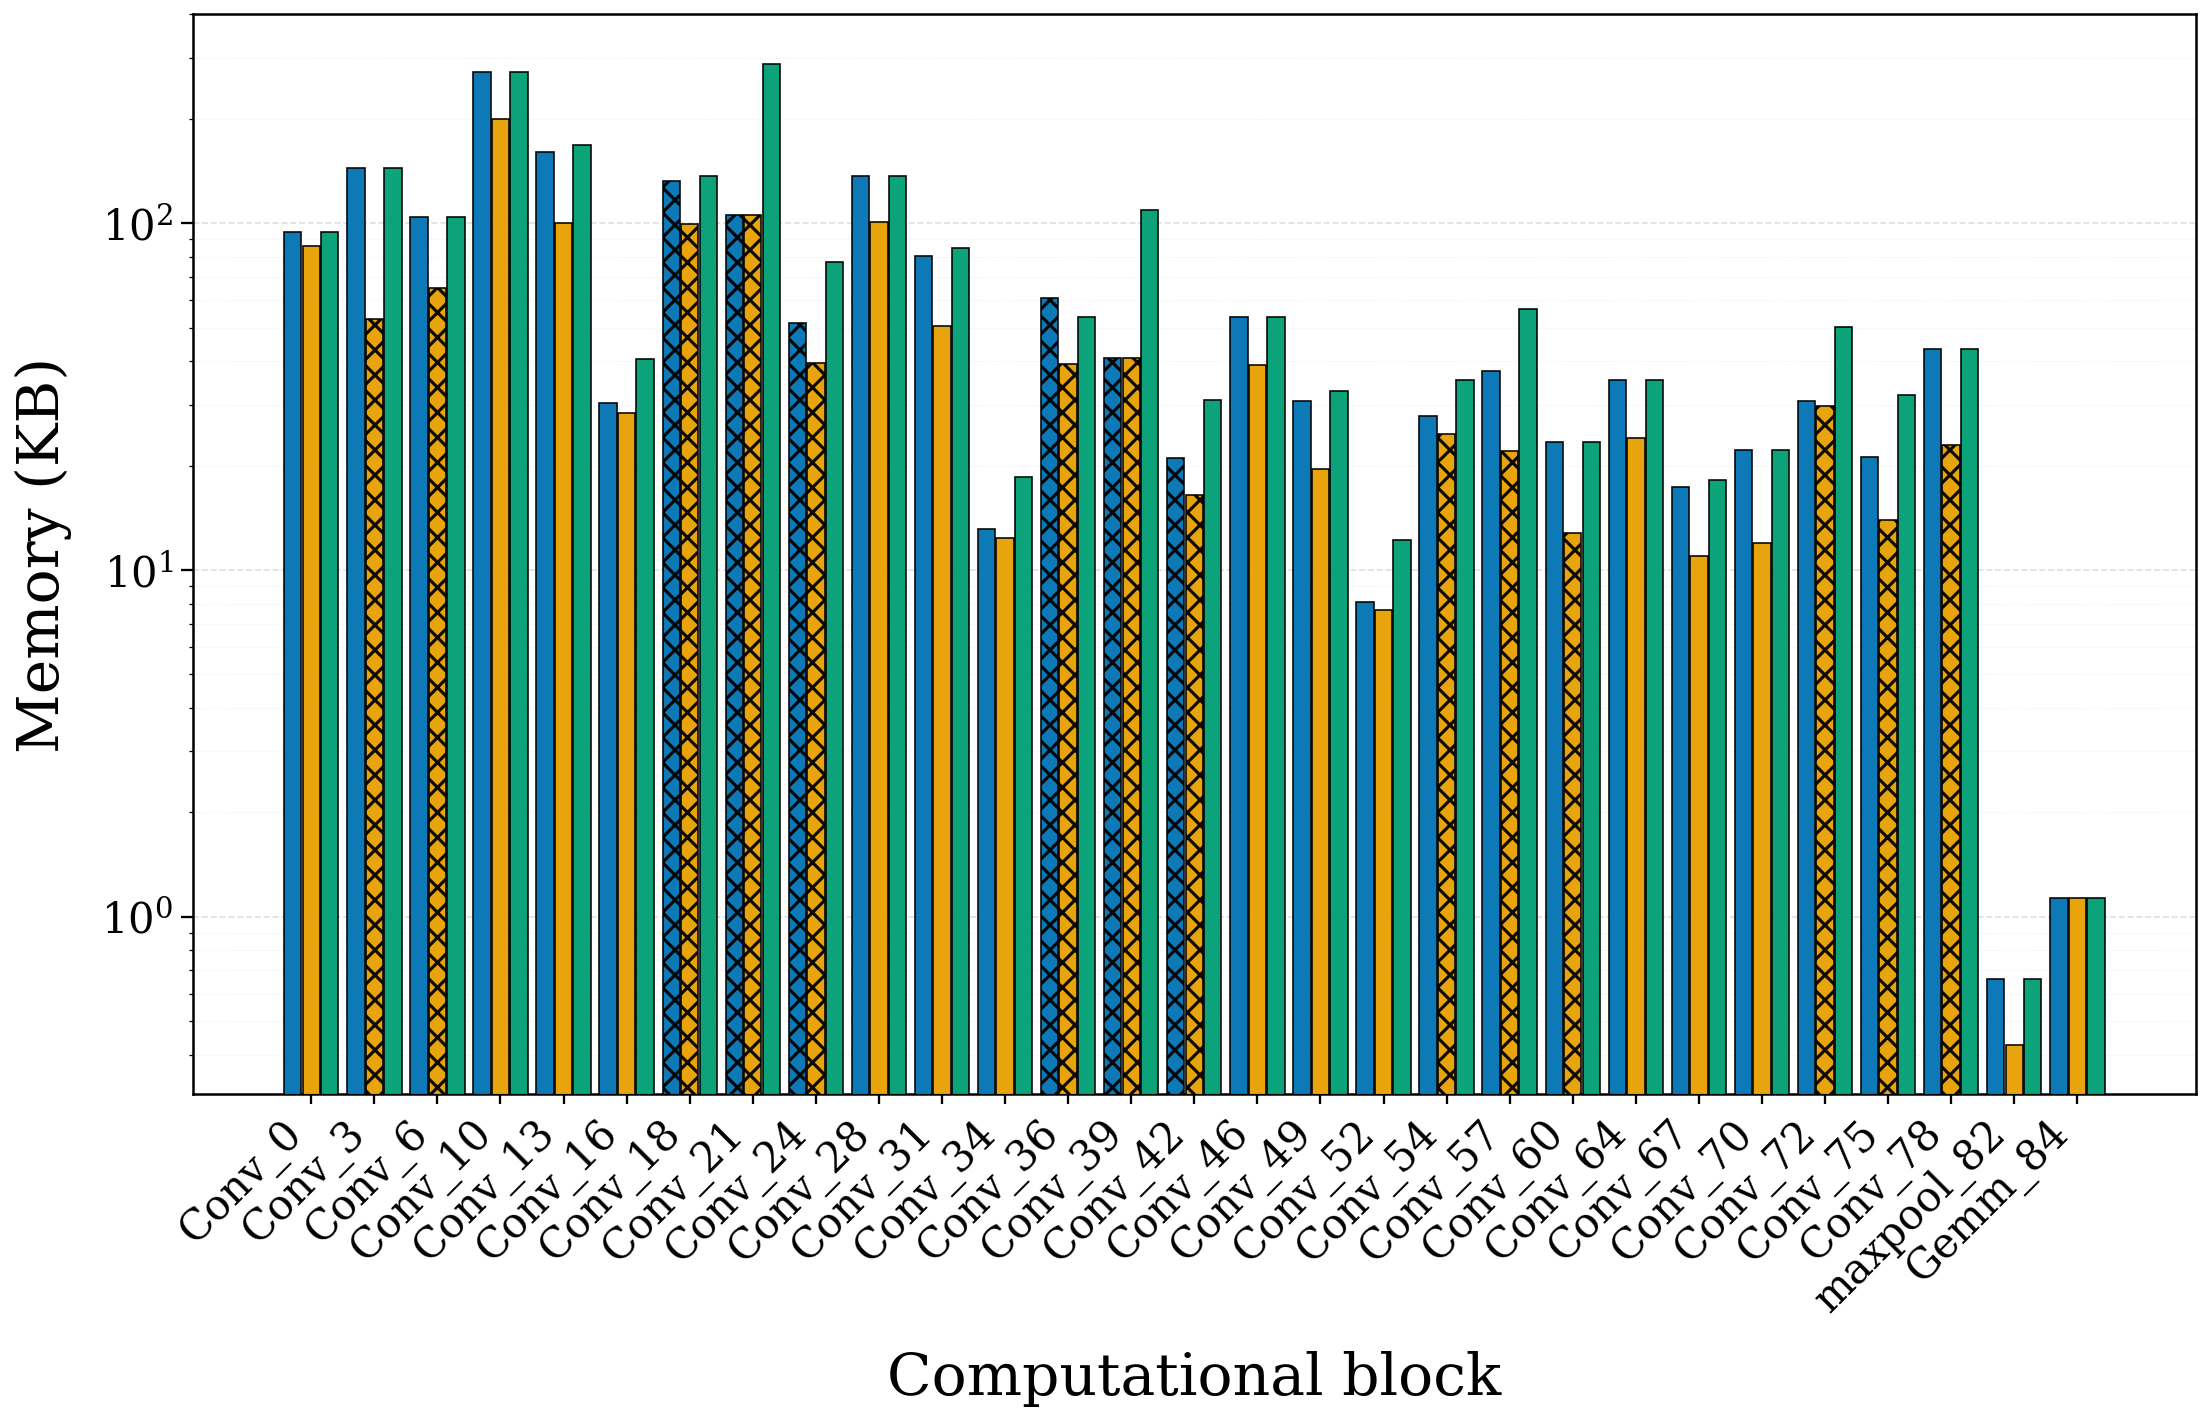

In [ ]:
fig, ax = plt.subplotsfigsize=FIGURE_SIZE

memory_plot_values = memory_values_kb.copy()
memory_plot_values[memory_plot_values <= 0] = np.nan

draw_block_bars(
    ax=ax,
    values=memory_plot_values,
    implementations=block_implementations
)

format_axis(
    ax=ax,
    labels=block_labels,
    ylabel="Memory (KB)",
    logarithmic=True
)

# add_combined_legend(ax)

fig.subplots_adjust(
    left=0.09,
    right=0.98,
    top=0.97,
    bottom=0.25
)

plt.savefig(
    f"./output/images/{model_name}-mem.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


### BOPs

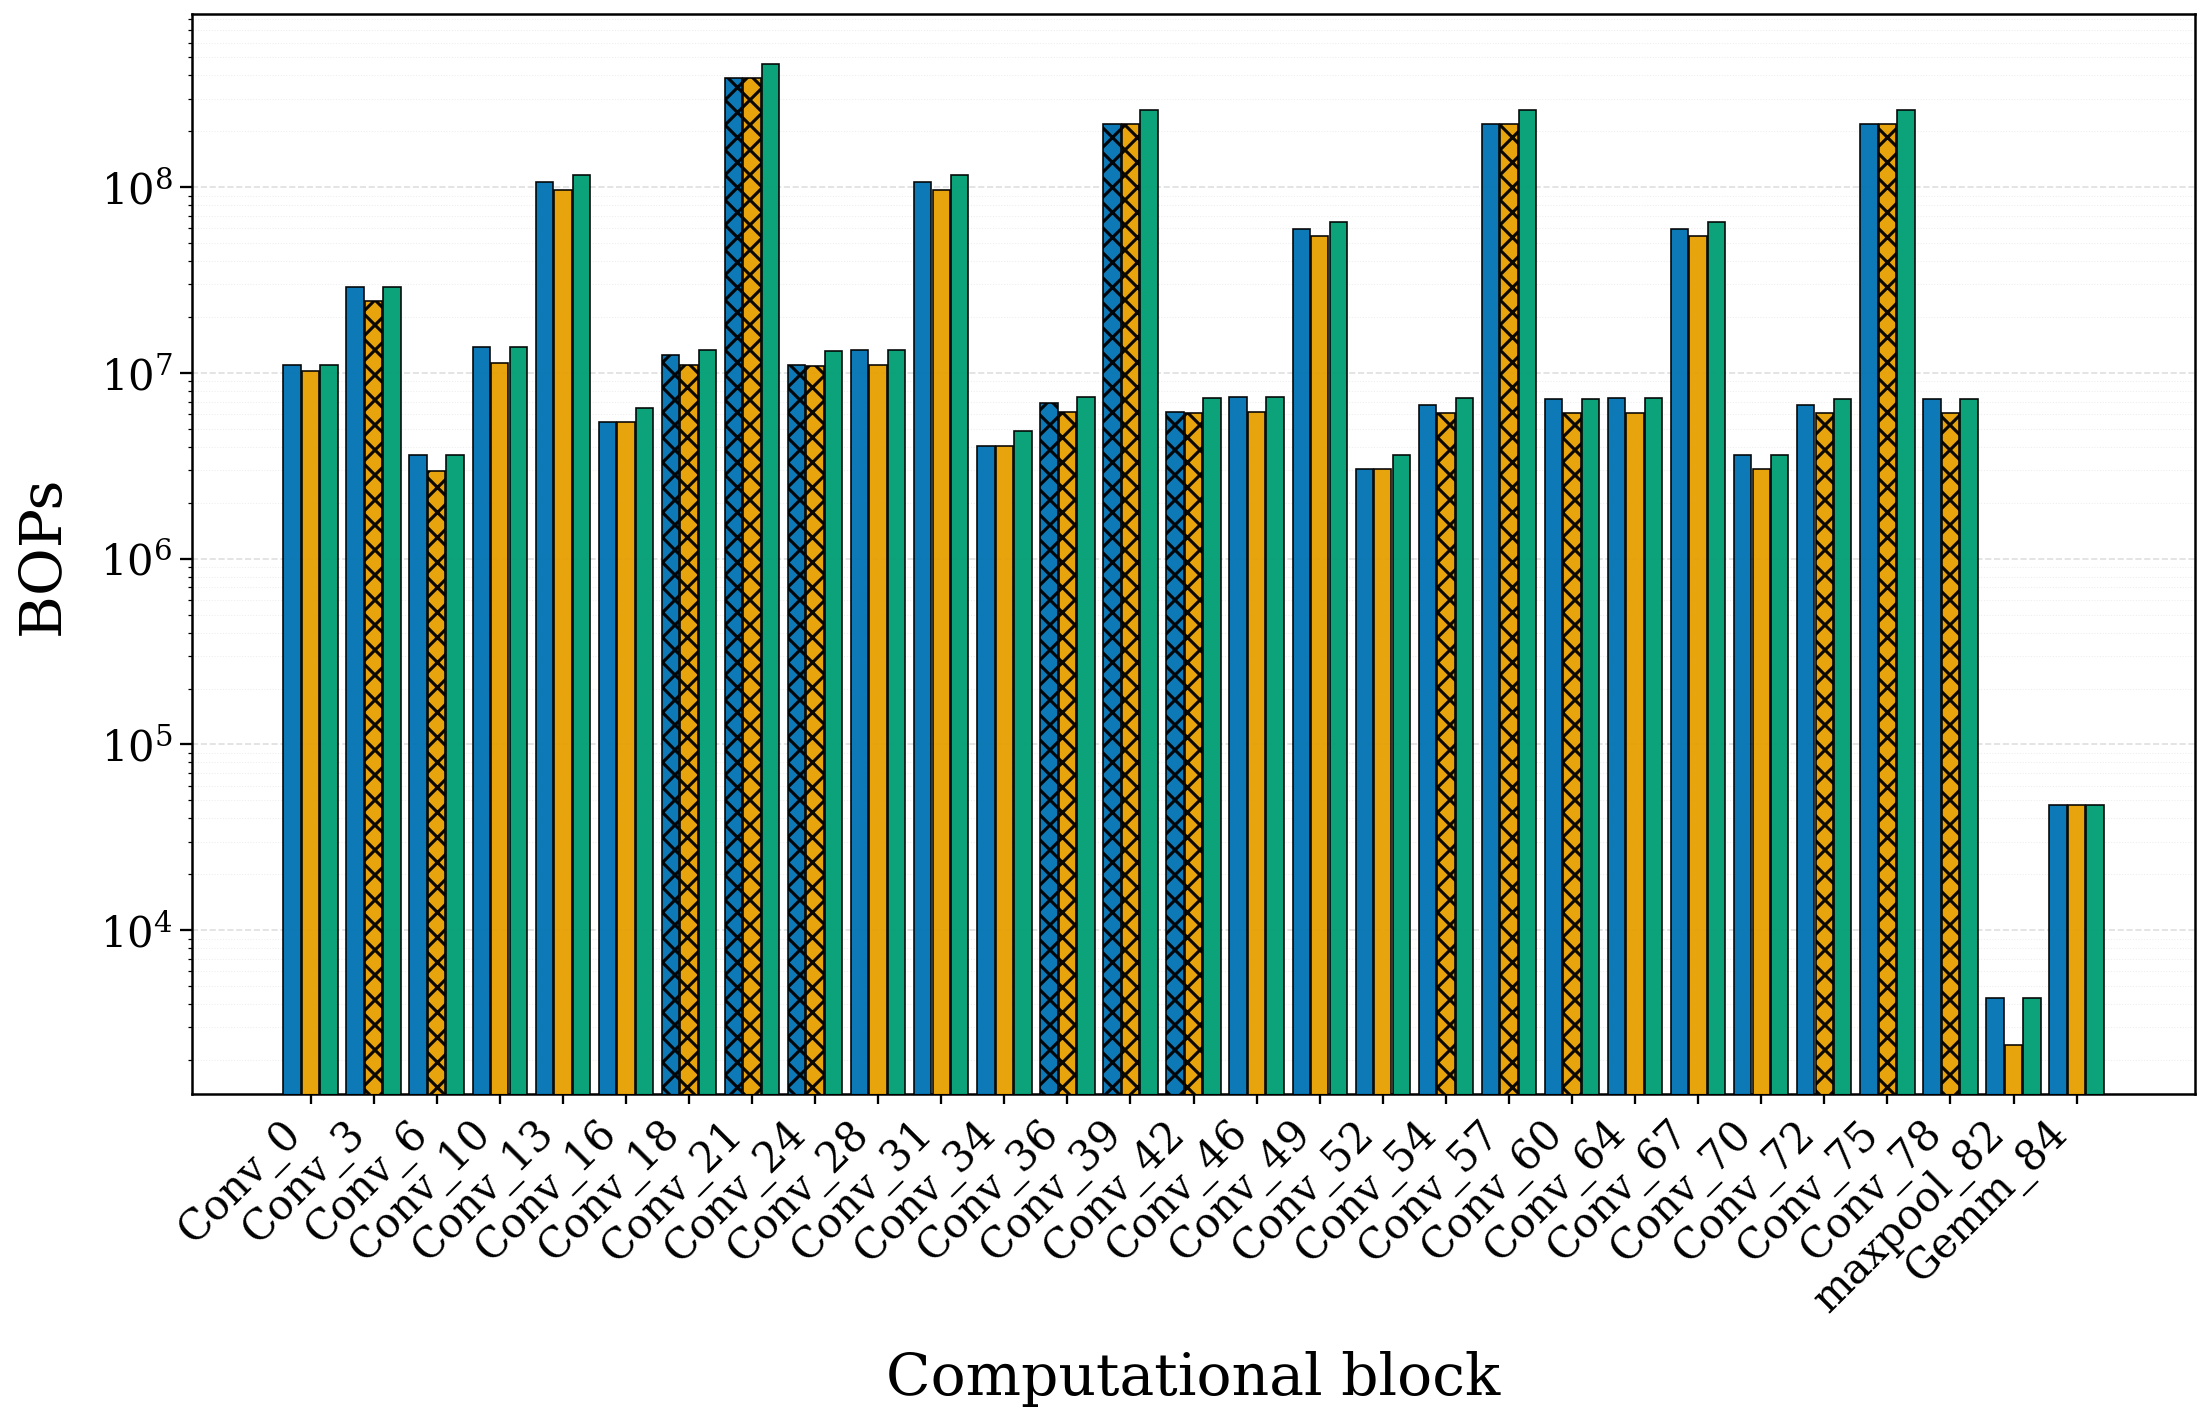

In [ ]:
fig, ax = plt.subplots(figsize=FIGURE_SIZE)

bops_plot_values = bops_values.copy()
bops_plot_values[bops_plot_values <= 0] = np.nan

draw_block_bars(
    ax=ax,
    values=bops_plot_values,
    implementations=block_implementations
)

format_axis(
    ax=ax,
    labels=block_labels,
    ylabel="BOPs",
    logarithmic=True
)

# add_combined_legend(ax)

fig.subplots_adjust(
    left=0.09,
    right=0.98,
    top=0.97,
    bottom=0.25
)

plt.savefig(
    f"./output/images/{model_name}-bop.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

## Platform-aware analysis

### plot setup

In [ ]:
def short_layer_name(name):
    name = str(name).strip()
    replacements = [
        ("ReluFullyConnected", "RFC"),
        ("ReluConvolution", "RC"),
        ("ReluPooling", "RP"),
        ("FullyConnected", "FC"),
        ("Convolution", "C"),
        ("Addition", "Add"),
        ("Pooling", "P"),
    ]
    for long_name, short_name in replacements:
        if name.startswith(long_name):
            return name.replace(long_name, short_name, 1)
    return name


def plot_platforms(
    dataframes,
    platform_labels,
    layer_column,
    value_column,
    ylabel,
    title=None,
    log_scale=False,
    divide_by=1.0,
    figsize=FIGURE_SIZE,
    save_path=None,
):
    reference_layers = dataframes[0][layer_column].astype(str).tolist()
    
    short_labels = [
        short_layer_name(layer)
        for layer in reference_layers
    ]

    for platform_label, df in zip(platform_labels[1:], dataframes[1:]):
        current_layers = df[layer_column].astype(str).tolist()
        
        if current_layers != reference_layers:
            raise ValueError(
                f"Layer order for {platform_label} does not match "
                "the first platform."
            )

    num_layers = len(reference_layers)
    num_platforms = len(dataframes)

    if num_platforms > len(CASE_COLORS):
        raise ValueError(
            f"Only {len(CASE_COLORS)} colors are defined."
        )

    x = np.arange(num_layers)

    total_group_width = 0.84
    bar_width = total_group_width / num_platforms

    fig, ax = plt.subplots(figsize=figsize)

    for platform_index, (platform_label, df) in enumerate(zip(platform_labels, dataframes)):
        values = pd.to_numeric(df[value_column], errors="coerce").to_numpy(dtype=float) / divide_by
        

        if log_scale:
            values = values.copy()
            values[values <= 0] = np.nan

        offset = (
            platform_index - (num_platforms - 1) / 2
        ) * bar_width

        ax.bar(
            x + offset,
            values,
            width=bar_width * 0.94,
            label=platform_label,
            color=CASE_COLORS[platform_index],
            edgecolor="black",
            linewidth=0.45,
            alpha=0.95,
            zorder=3
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        short_labels,
        rotation=90,
        ha="center",
        fontsize=X_TICK_FONT_SIZE
    )

    ax.set_xlabel(
        "Layer",
        fontsize=LABEL_FONT_SIZE
    )
    ax.set_ylabel(
        ylabel,
        fontsize=LABEL_FONT_SIZE
    )

    if title is not None:
        ax.set_title(title)

    if log_scale:
        ax.set_yscale("log")

        ax.grid(
            axis="y",
            which="major",
            linestyle="--",
            linewidth=0.7,
            alpha=0.35
        )

        ax.grid(
            axis="y",
            which="minor",
            linestyle=":",
            linewidth=0.5,
            alpha=0.18
        )

    else:
        ax.grid(
            axis="y",
            linestyle="--",
            linewidth=0.7,
            alpha=0.35
        )

    ax.set_axisbelow(True)

    ax.legend(loc="best", frameon=True)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    plt.show()
    plt.close(fig)
    
    

def plot_cases(
    dataframes,
    case_labels,
    layer_column,
    value_column,
    ylabel,
    title=None,
    log_scale=False,
    divide_by=1.0,
    figsize=FIGURE_SIZE,
    save_path=None,
):
    reference_layers = dataframes[0][layer_column].astype(str).tolist()
    
    short_labels = [
        short_layer_name(layer)
        for layer in reference_layers
    ]

    for case_label, df in zip(case_labels[1:], dataframes[1:]):
        current_layers = df[layer_column].astype(str).tolist()
        if current_layers != reference_layers:
            raise ValueError(
                f"Layer order for {case_label} does not match "
                "the first case."
            )

    num_layers = len(reference_layers)
    num_cases = len(dataframes)

    if num_cases > len(CASE_COLORS):
        raise ValueError(
            f"Only {len(CASE_COLORS)} case colors are defined."
        )

    x = np.arange(num_layers)
    total_group_width = 0.84
    bar_width = total_group_width / num_cases

    fig, ax = plt.subplots(figsize=figsize)
    for case_index, (case_label, df) in enumerate(
        zip(case_labels, dataframes)
    ):
        values = (
            pd.to_numeric(df[value_column], errors="coerce")
            .to_numpy(dtype=float)
            / divide_by
        )

        if log_scale:
            values[values <= 0] = np.nan

        offset = (
            case_index - (num_cases - 1) / 2
        ) * bar_width

        ax.bar(
            x + offset,
            values,
            width=bar_width * 0.94,
            label=case_label,
            color=CASE_COLORS[case_index],
            edgecolor="black",
            linewidth=0.45,
            alpha=0.95,
            zorder=3
        )


    ax.set_xticks(x)
    ax.set_xticklabels(
        short_labels,
        rotation=90,
        ha="center",
        fontsize=X_TICK_FONT_SIZE
    )

    ax.set_xlabel("Layer", fontsize=LABEL_FONT_SIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_FONT_SIZE)

    if title is not None:
        ax.set_title(title)

    if log_scale:
        ax.set_yscale("log")

        ax.grid(
            axis="y",
            which="major",
            linestyle="--",
            linewidth=0.7,
            alpha=0.35
        )

        ax.grid(
            axis="y",
            which="minor",
            linestyle=":",
            linewidth=0.5,
            alpha=0.18
        )

    else:
        ax.grid(
            axis="y",
            linestyle="--",
            linewidth=0.7,
            alpha=0.35
        )

    ax.set_axisbelow(True)
    ax.legend(loc="best", frameon=True)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    plt.show()
    plt.close(fig)

In [ ]:
def load_step3_cases(
    model_name,
    platform,
    output_dir="./output",
):
    pattern = os.path.join(
        output_dir,
        f"STEP3_paltform*{platform}*{model_name}*case*.csv"
    )

    files = sorted(glob.glob(pattern))

    print("Search pattern:")
    print(pattern)

    print("\nFiles found:")
    for filepath in files:
        print("  ", os.path.basename(filepath))


    if not files:
        raise FileNotFoundError(
            f"No STEP3 files found for model '{model_name}' "
            f"and platform {platform}."
        )

    case_regex = re.compile(
        r"_case[\s_]*(\d+)\.csv$",
        flags=re.IGNORECASE
    )


    parsed_files = []
    for filepath in files:
        filename = os.path.basename(filepath)
        match = case_regex.search(filename)

        if match is None:
            print(
                f"WARNING: could not extract case number from: "
                f"{repr(filename)}"
            )
            continue

        case_number = int(match.group(1))
        parsed_files.append((case_number, filepath))

    if not parsed_files:
        raise ValueError(
            "Files were found, but no case number could be "
            "extracted from their filenames."
        )

    parsed_files.sort(key=lambda item: item[0])
    required_columns = {
        "layer_name",
        "MACs",
        "num_cycles",
        "MAC_per_cycle",
        "num_cores",
        "L1_mem",
        "L2_mem",
        "L1_tiling",
        "L2_tiling",
    }

    dataframes = []
    case_labels = []

    for case_number, filepath in parsed_files:
        df = pd.read_csv(filepath)
        df.columns = df.columns.astype(str).str.strip()
        missing_columns = required_columns - set(df.columns)
 
        if missing_columns:
            raise ValueError(
                f"\nFile:\n{filepath}\n\n"
                f"is missing columns:\n"
                f"{sorted(missing_columns)}\n\n"
                f"Available columns:\n"
                f"{df.columns.tolist()}"
            )

        df = df.copy()
        df["layer_name"] = df["layer_name"].astype(str).str.strip()

        numeric_columns = [
            "MACs",
            "num_cycles",
            "MAC_per_cycle",
            "num_cores",
            "L1_mem",
            "L2_mem",
            "L1_tiling",
            "L2_tiling",
        ]

        for column in numeric_columns:
            df[column] = pd.to_numeric(df[column], errors="coerce")
        dataframes.append(df)
        case_labels.append(f"Case {case_number}")

    return dataframes, case_labels


def load_step3_platforms(
    model_name,
    case_number,
    output_dir="./output",
):
    files = glob.glob(os.path.join(output_dir, "STEP3_*.csv"))

    if not files:
        raise FileNotFoundError(
            f"No STEP3 CSV files found in:\n{output_dir}"
        )

    filename_regex = re.compile(
        r"^STEP3_"
        r"(?:platform|paltform)"
        r"[\s_]*(\d+)_"
        r"(.+?)_case"
        r"[\s_]*(\d+)"
        r"\.csv$",
        flags=re.IGNORECASE
    )

    parsed_files = []

    for filepath in files:
        filename = os.path.basename(filepath)
        match = filename_regex.match(filename)
        if match is None:
            continue

        platform_number = int(match.group(1))
        file_model = match.group(2).strip()
        file_case = int(match.group(3))

        if (
            file_model.lower() == model_name.lower()
            and file_case == case_number
        ):
            parsed_files.append((platform_number, filepath))

    parsed_files.sort(key=lambda item: item[0])

    if not parsed_files:
        raise FileNotFoundError(
            f"No STEP3 files found for:\n"
            f"model = {model_name}\n"
            f"case = {case_number}"
        )

    required_columns = {
        "layer_name",
        "MACs",
        "num_cycles",
        "MAC_per_cycle",
        "num_cores",
        "L1_mem",
        "L2_mem",
        "L1_tiling",
        "L2_tiling",
    }

    platform_dataframes = []
    platform_labels = []

    for platform_number, filepath in parsed_files:
        df = pd.read_csv(filepath)
        df.columns = df.columns.astype(str).str.strip()
        missing_columns = required_columns - set(df.columns)
        if missing_columns:
            raise ValueError(
                f"{filepath} is missing columns:\n"
                f"{sorted(missing_columns)}"
            )

        df = df.copy()
        df["layer_name"] = df["layer_name"].astype(str).str.strip()
        
        numeric_columns = [
            "MACs",
            "num_cycles",
            "MAC_per_cycle",
            "num_cores",
            "L1_mem",
            "L2_mem",
            "L1_tiling",
            "L2_tiling",
        ]

        for column in numeric_columns:
            df[column] = pd.to_numeric(df[column], errors="coerce")
            
        platform_dataframes.append(df)
        platform_labels.append(f"Platform {platform_number}")

    return platform_dataframes, platform_labels

In [ ]:
model_name = "efficientnet"
platform = 1
case_number = 1


dataframes, case_labels = load_step3_cases(
    model_name=model_name,
    platform=platform,
    output_dir="./output",
)

platform_dataframes, platform_labels = load_step3_platforms(
    model_name=model_name,
    case_number=case_number,
    output_dir="./output",
)

Search pattern:
./output/STEP3_paltform*1*efficientnet*case*.csv

Files found:
   STEP3_paltform 1_efficientnet_case 1.csv
   STEP3_paltform 1_efficientnet_case 2.csv
   STEP3_paltform 1_efficientnet_case 3.csv

Loading STEP3 cases:
  Case 1: STEP3_paltform 1_efficientnet_case 1.csv
  Case 2: STEP3_paltform 1_efficientnet_case 2.csv
  Case 3: STEP3_paltform 1_efficientnet_case 3.csv
Loaded Platform 1: STEP3_paltform 1_efficientnet_case 1.csv
Loaded Platform 2: STEP3_paltform 2_efficientnet_case 1.csv
Loaded Platform 3: STEP3_paltform 3_efficientnet_case 1.csv


### analysis by case

In [275]:
model_name = "efficientnet"
platform = 1

dataframes, case_labels = load_step3_cases(
    model_name=model_name,
    platform=platform,
    output_dir="./output"
)

Search pattern:
./output/STEP3_paltform*1*efficientnet*case*.csv

Files found:
   STEP3_paltform 1_efficientnet_case 1.csv
   STEP3_paltform 1_efficientnet_case 2.csv
   STEP3_paltform 1_efficientnet_case 3.csv

Loading STEP3 cases:
  Case 1: STEP3_paltform 1_efficientnet_case 1.csv
  Case 2: STEP3_paltform 1_efficientnet_case 2.csv
  Case 3: STEP3_paltform 1_efficientnet_case 3.csv


Execution cycles

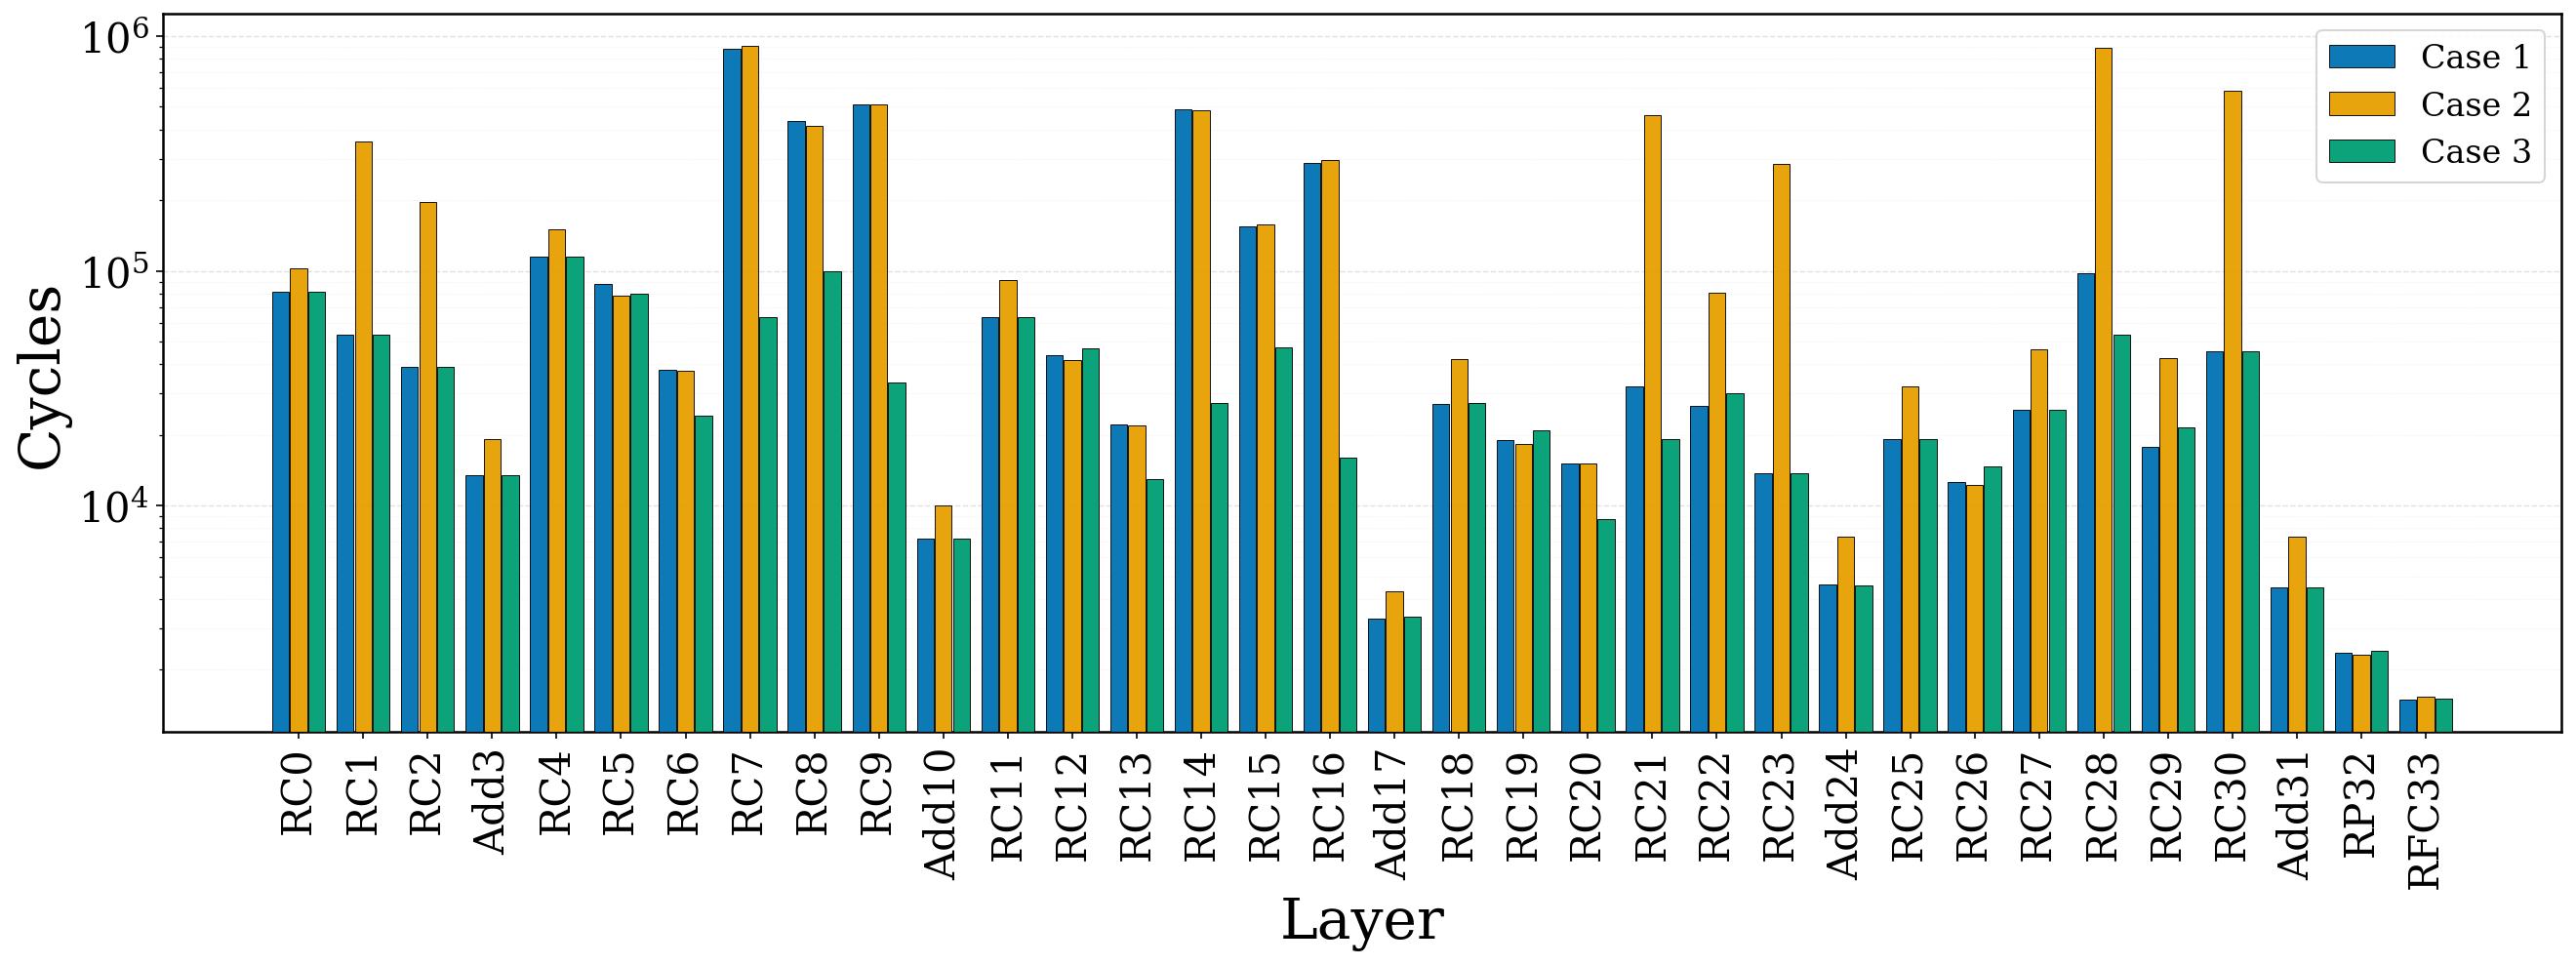

In [ ]:
plot_cases(
    dataframes=dataframes,
    case_labels=case_labels,
    layer_column="layer_name",
    value_column="num_cycles",
    ylabel="Cycles",
    log_scale=True,
    figsize=(18, 7),
    save_path=None
)

L1 tiling

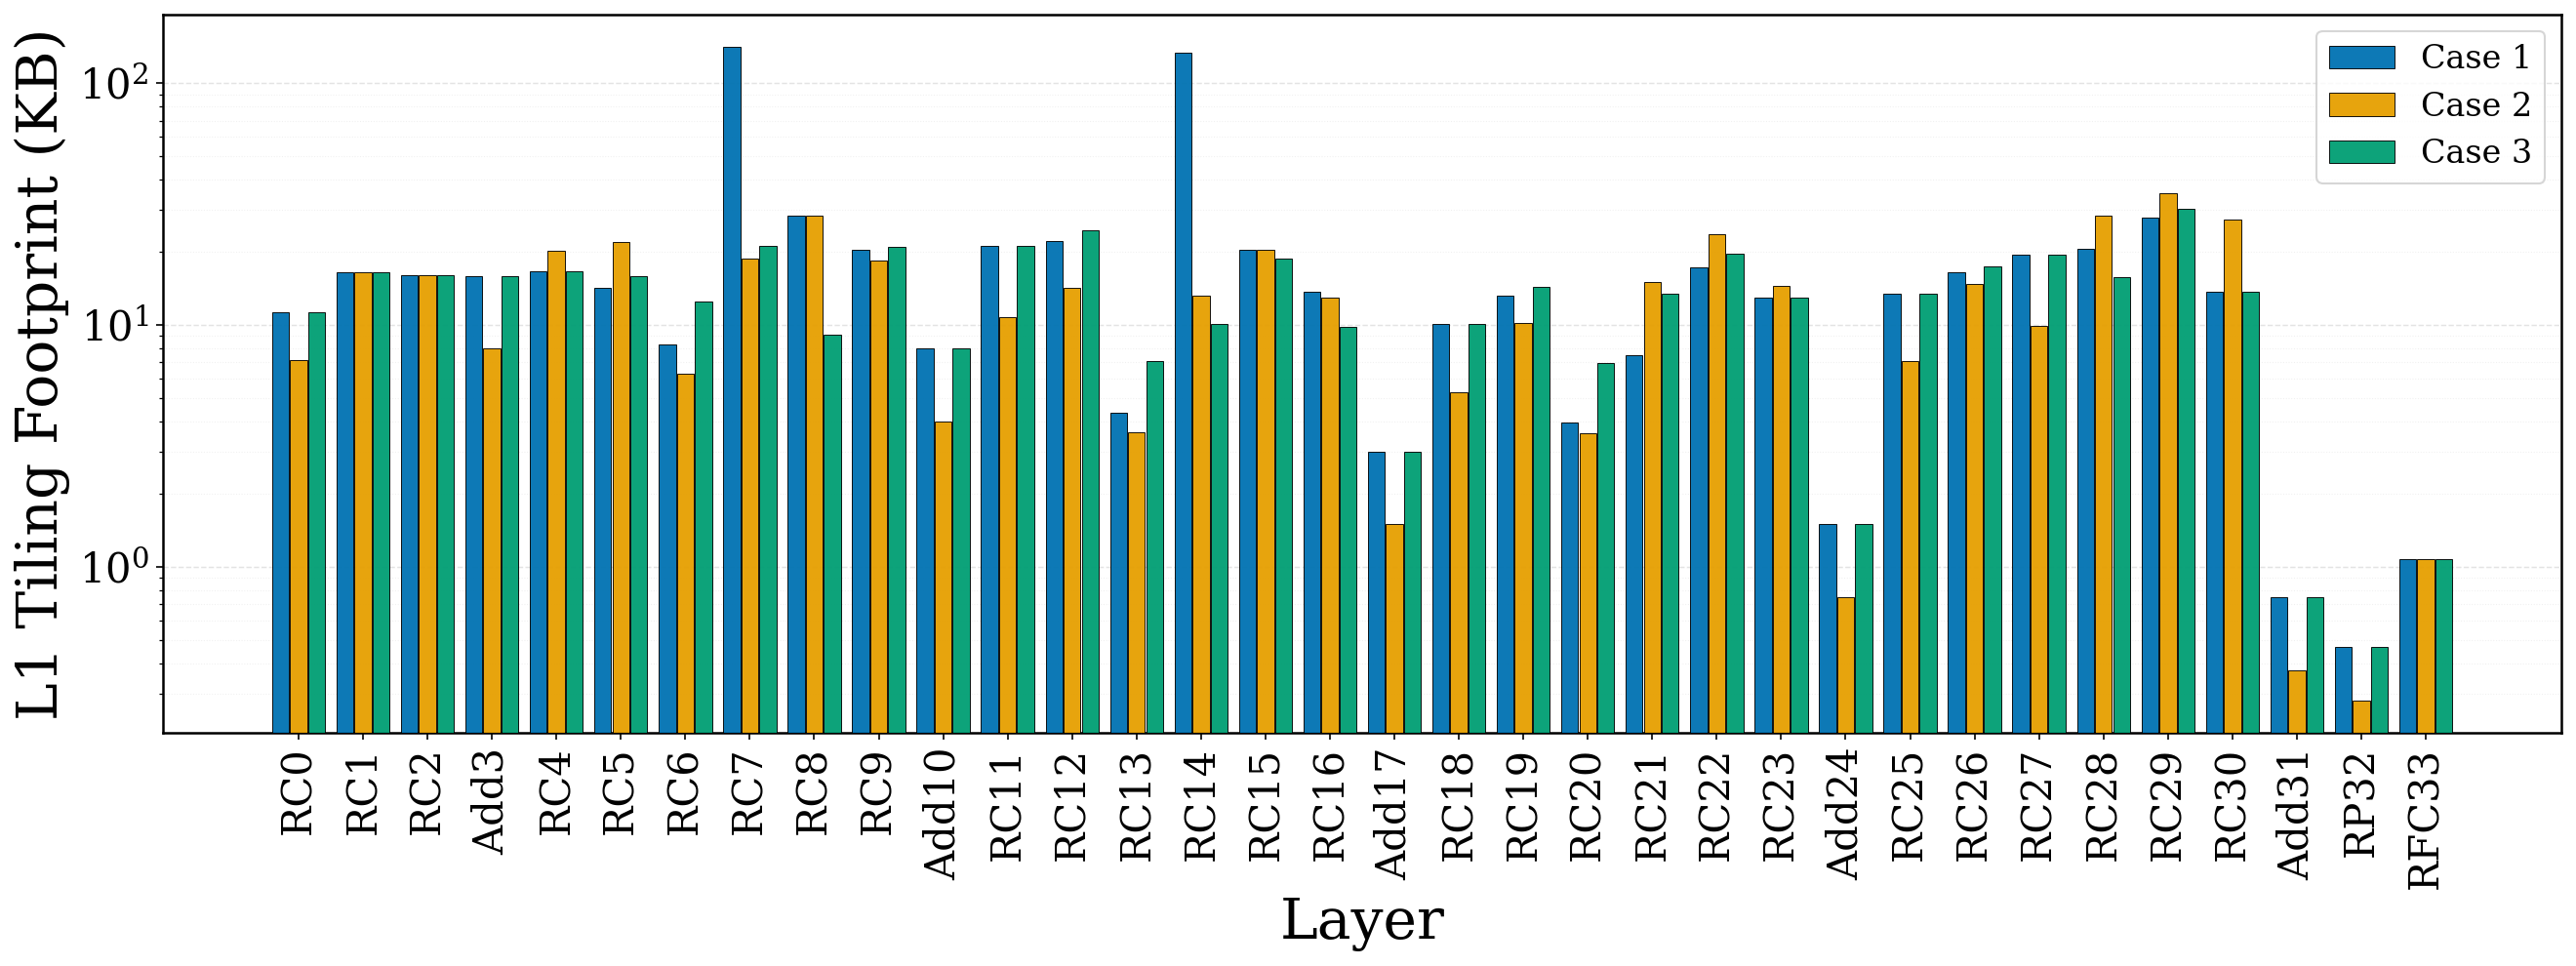

In [ ]:
plot_cases(
    dataframes=dataframes,
    case_labels=case_labels,
    layer_column="layer_name",
    value_column="L1_tiling",
    ylabel="L1 Tiling Footprint (KB)",
    divide_by=1024.0,
    log_scale=True,
    figsize=(18, 7),
    save_path=None
)

L2 tiling

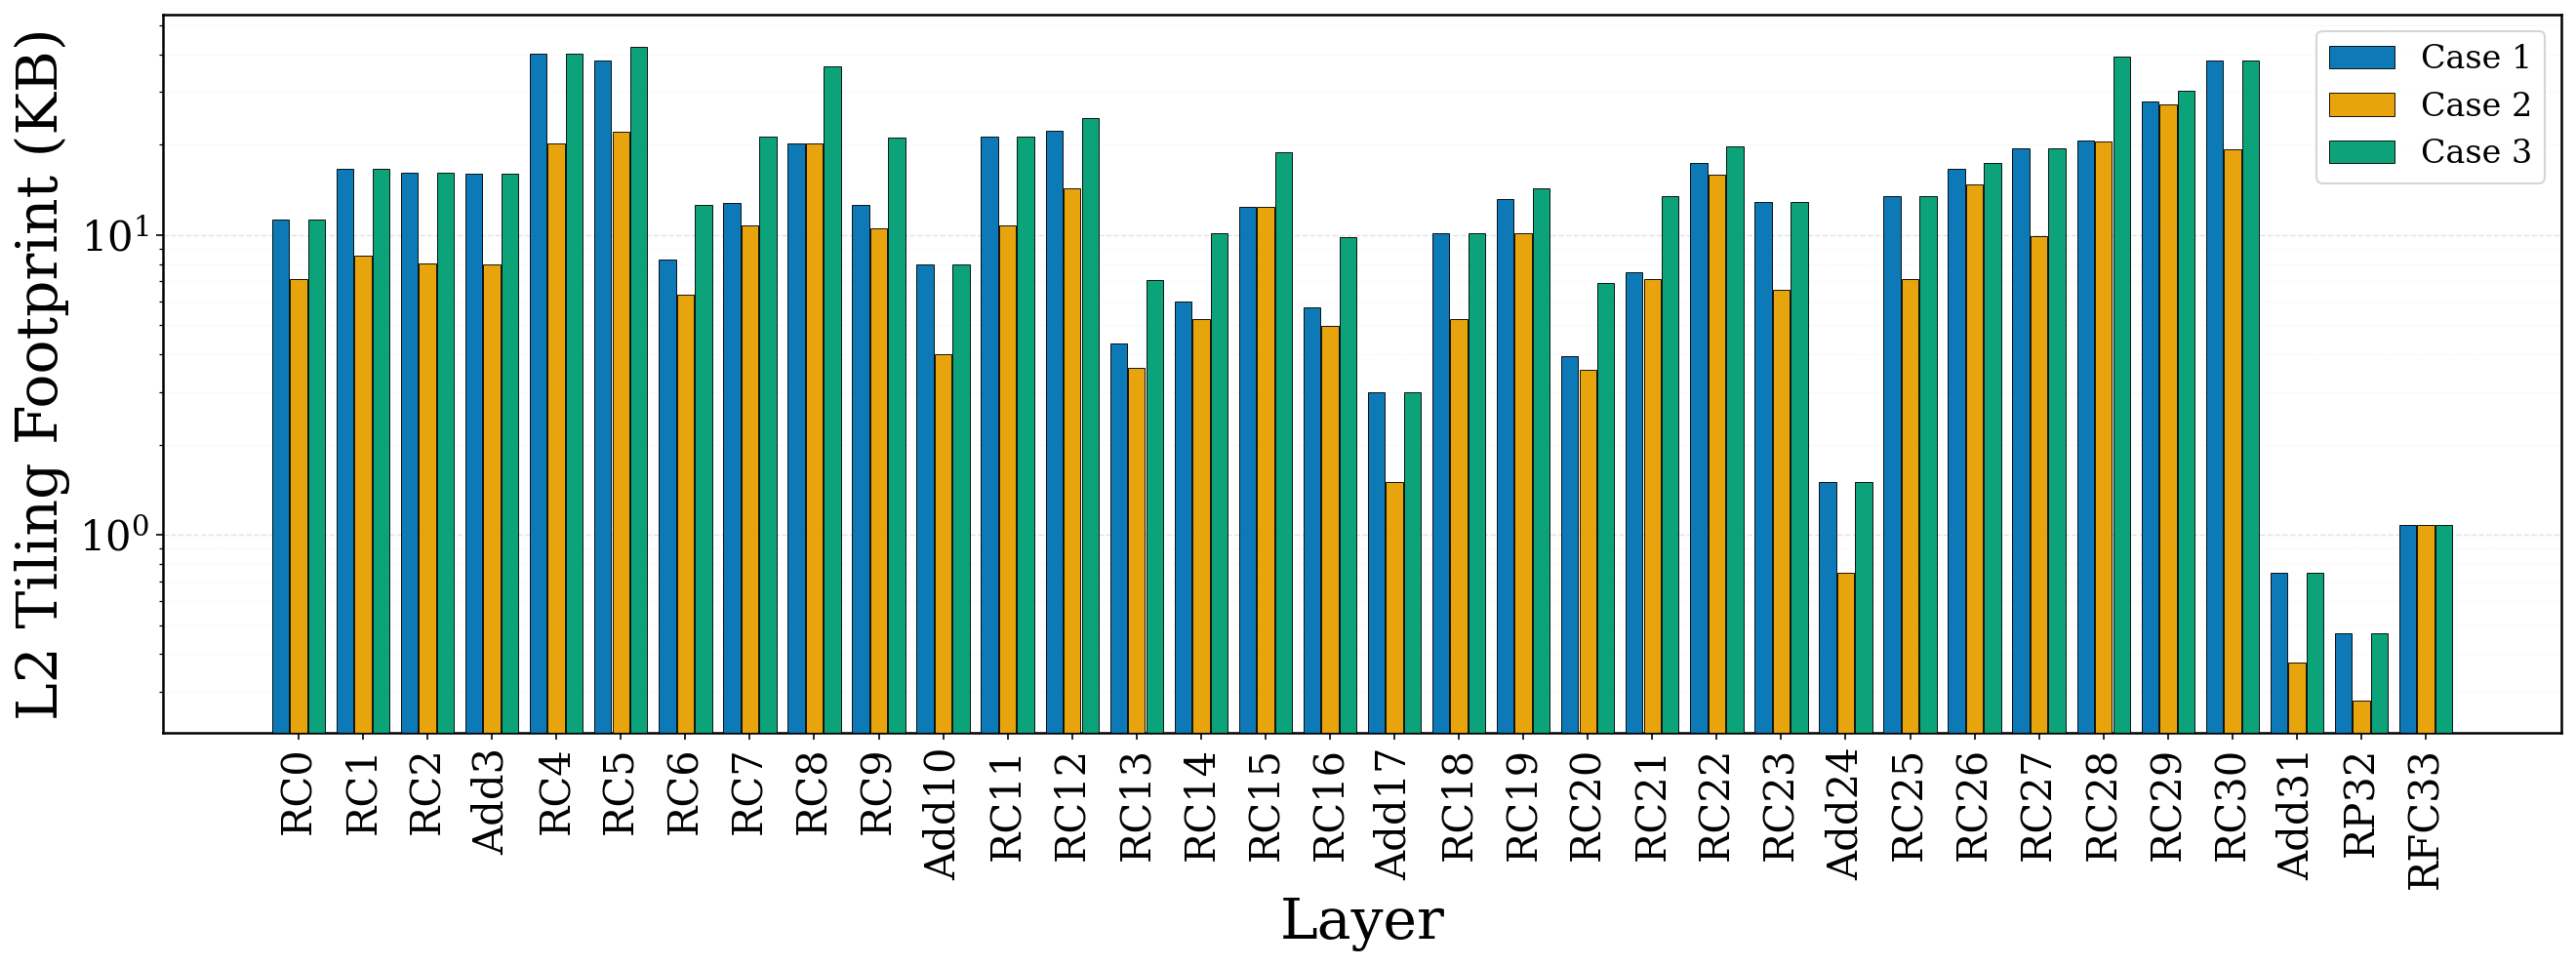

In [ ]:
plot_cases(
    dataframes=dataframes,
    case_labels=case_labels,
    layer_column="layer_name",
    value_column="L2_tiling",
    ylabel="L2 Tiling Footprint (KB)",
    divide_by=1024.0,
    log_scale=True,
    figsize=(18, 7),
    save_path=None
)

### analysis by platform

Execution cycles

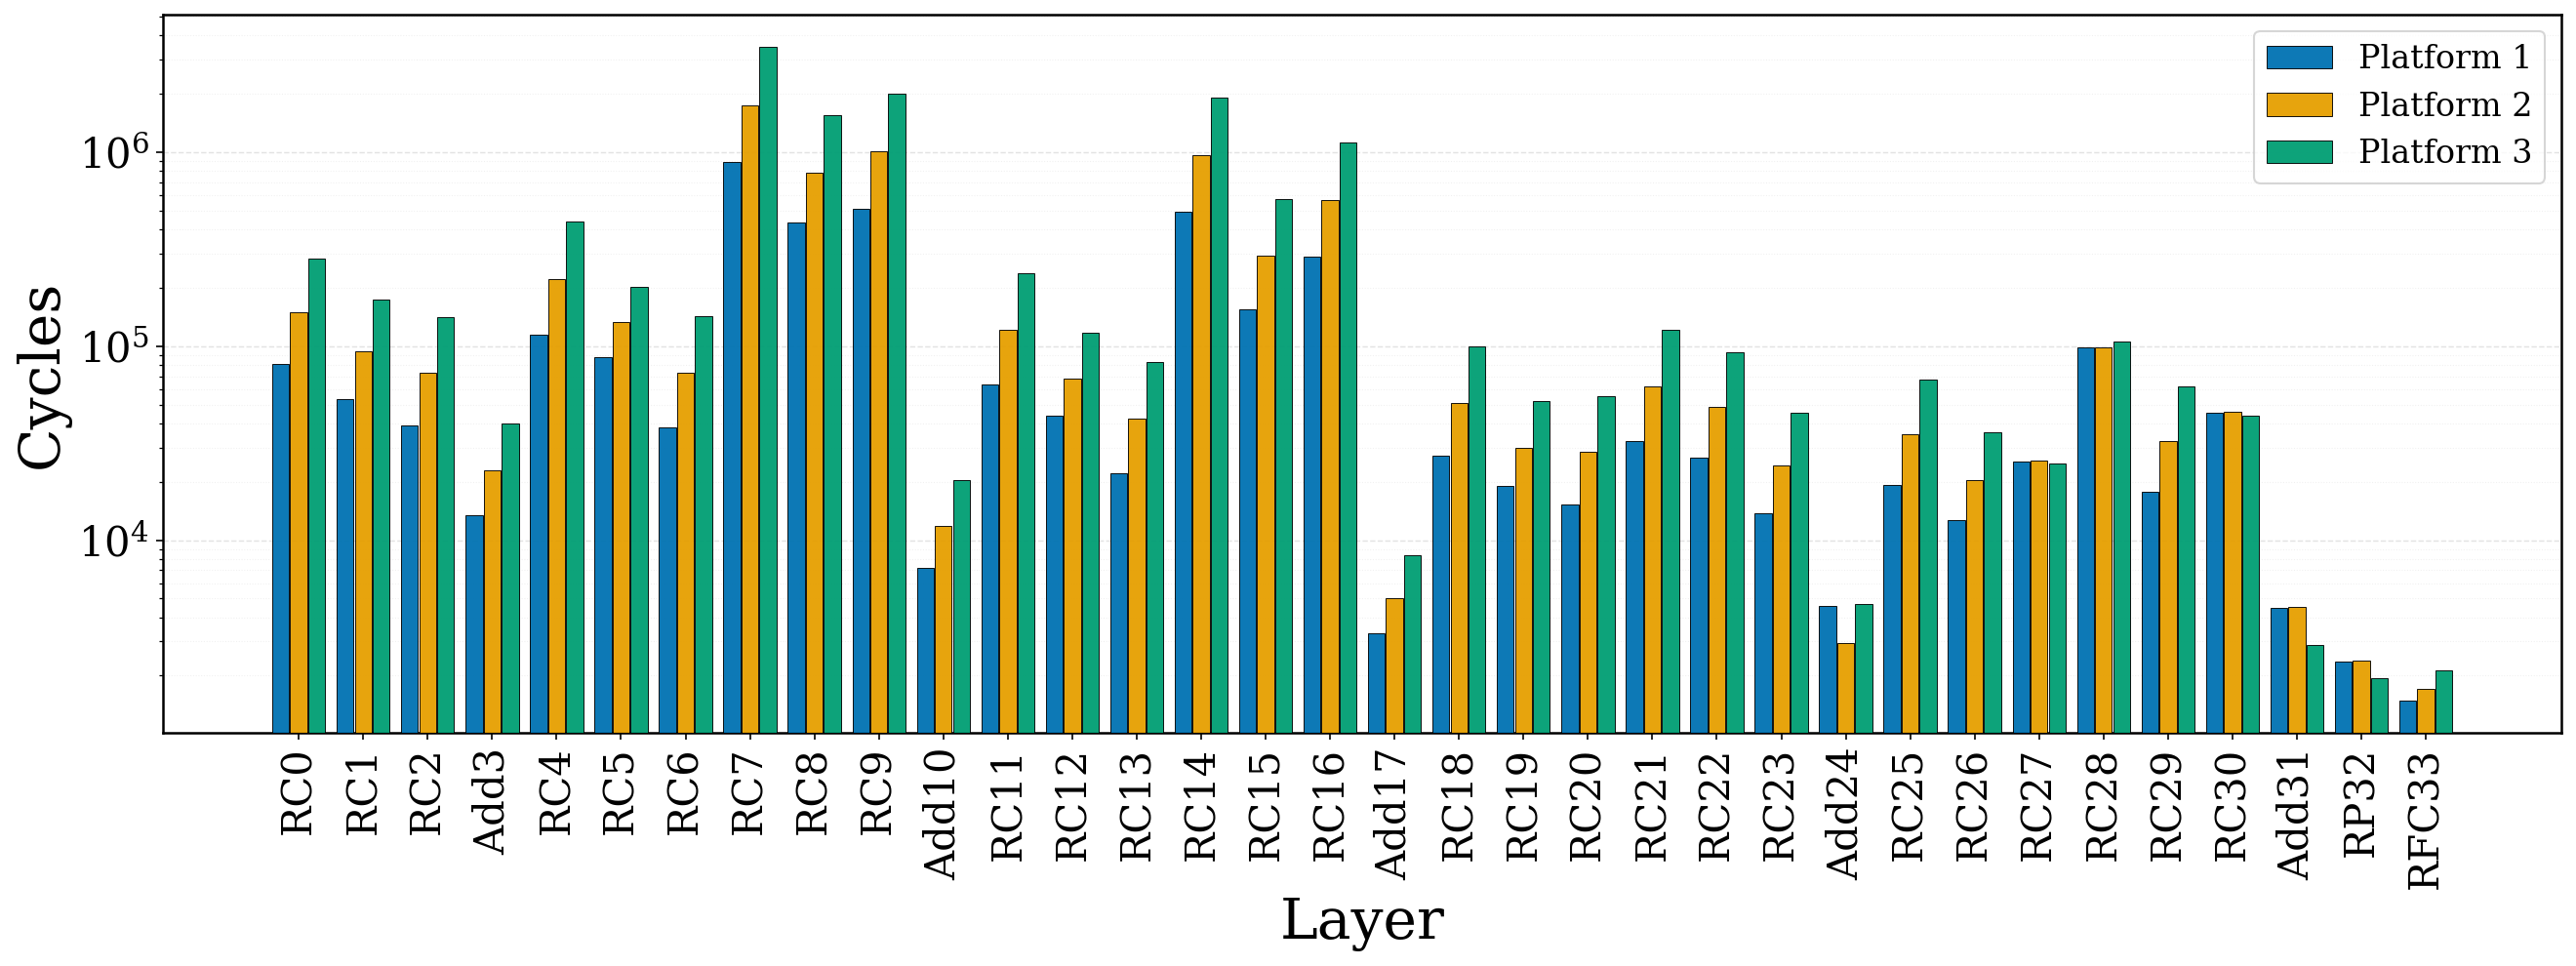

In [ ]:
plot_platforms(
    dataframes=platform_dataframes,
    platform_labels=platform_labels,
    layer_column="layer_name",
    value_column="num_cycles",
    ylabel="Cycles",
    log_scale=True,
    figsize=(18, 7)
)


L1 tiling

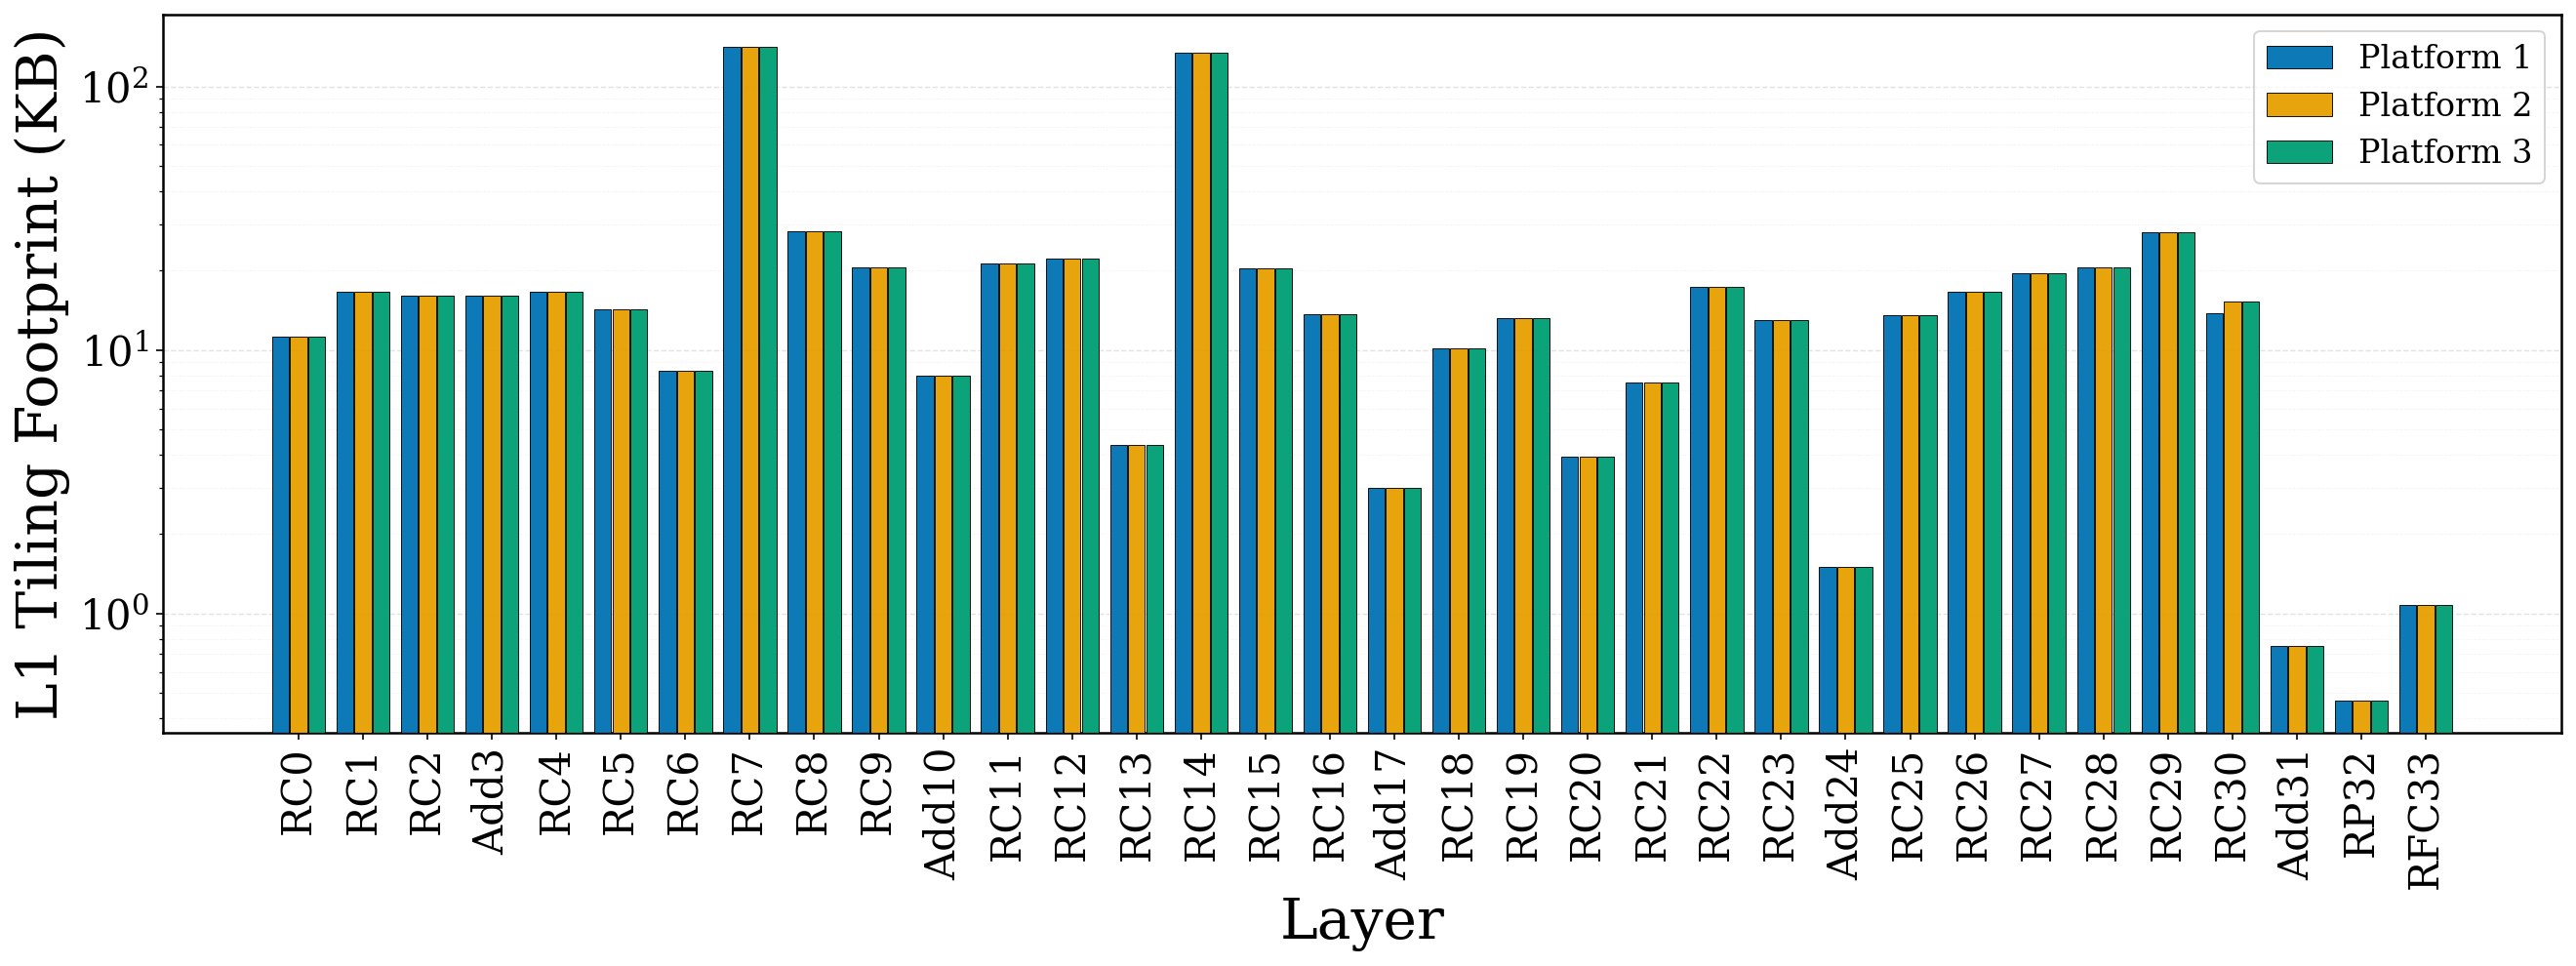

In [ ]:
plot_platforms(
    dataframes=platform_dataframes,
    platform_labels=platform_labels,
    layer_column="layer_name",
    value_column="L1_tiling",
    ylabel="L1 Tiling Footprint (KB)",
    divide_by=1024.0,
    log_scale=True,
    figsize=(18, 7)
)

L2 tiling

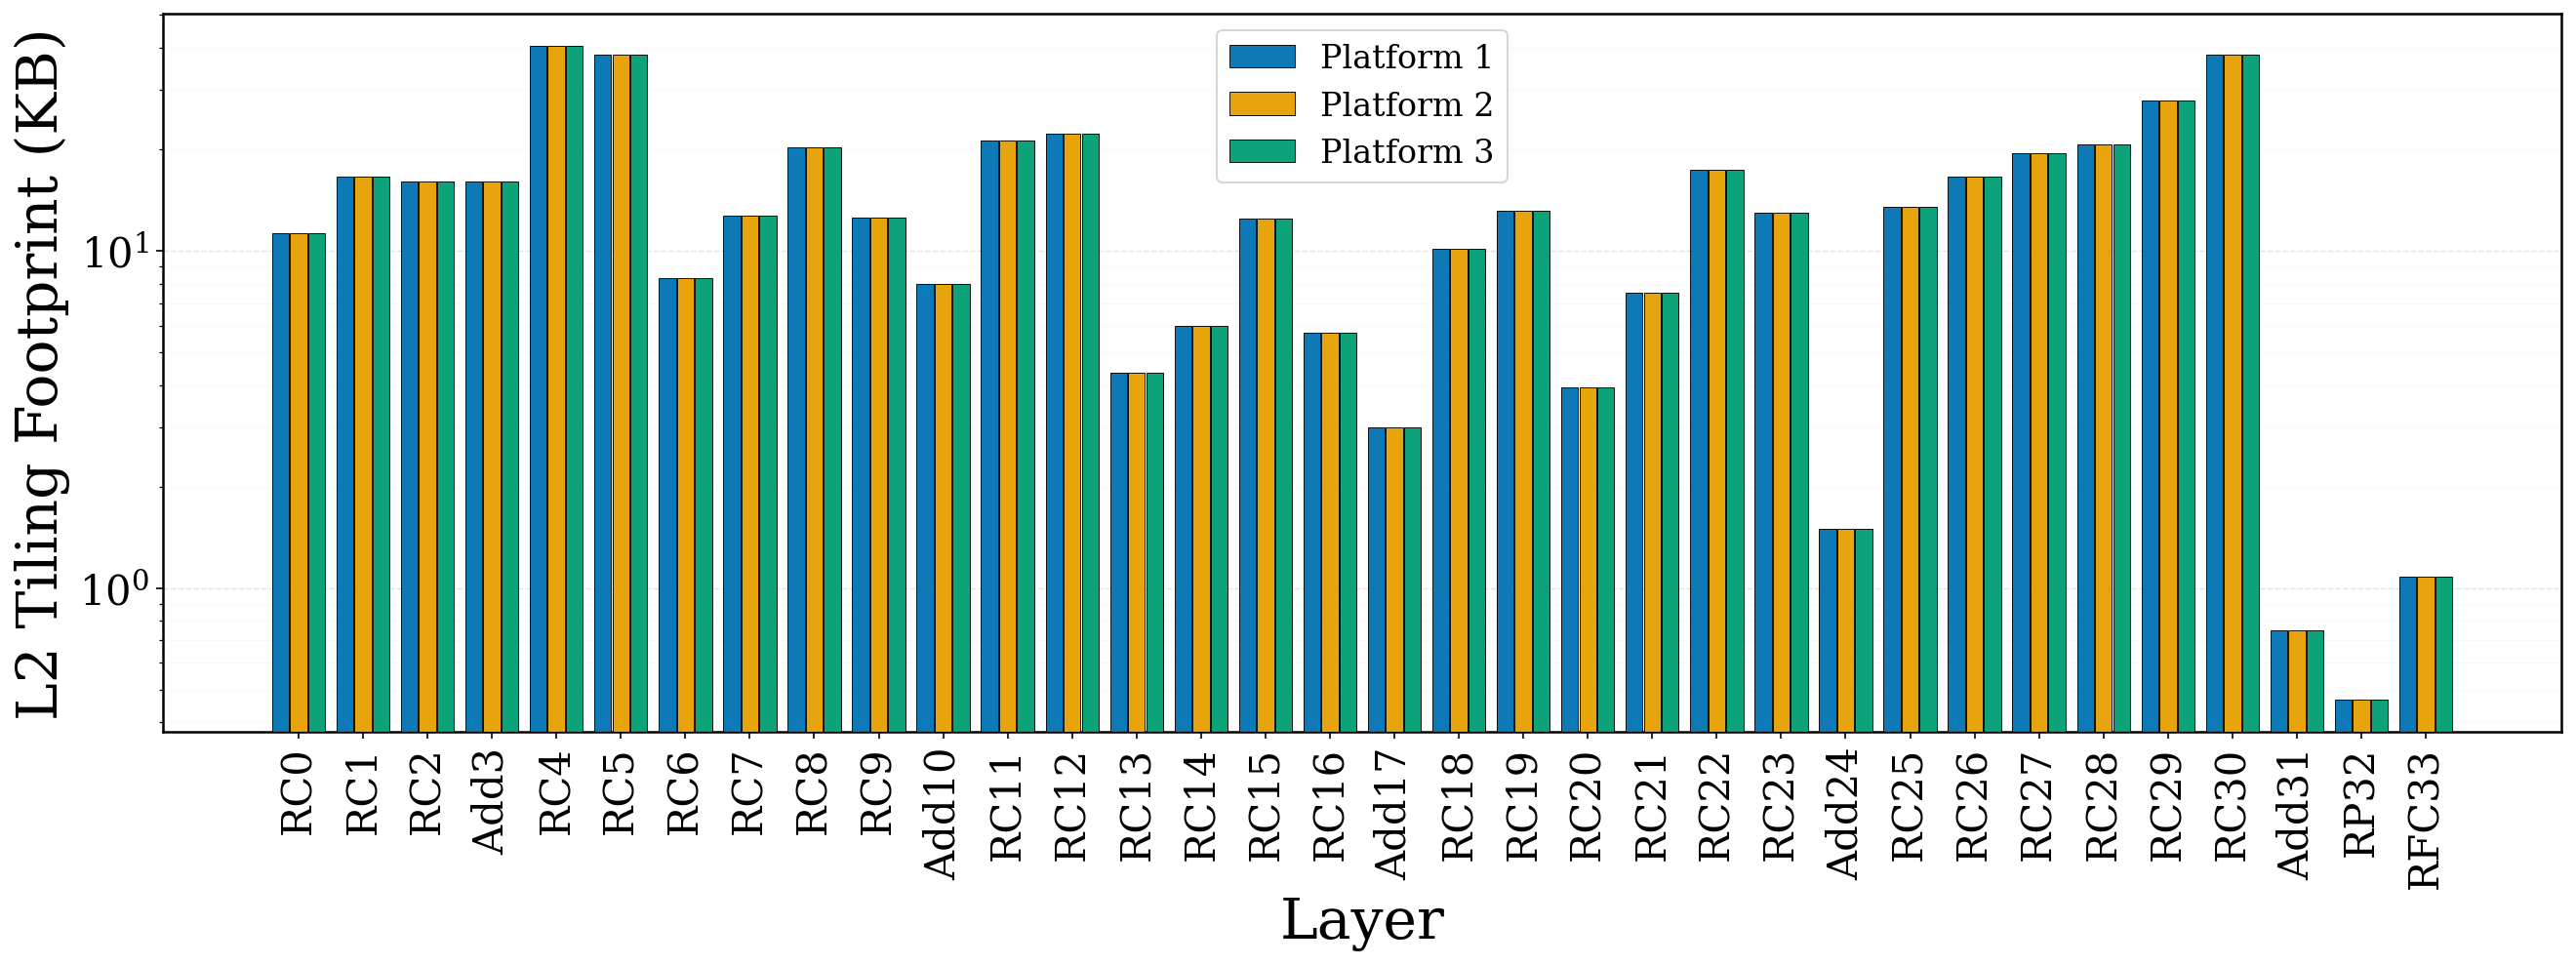

In [ ]:
plot_platforms(
    dataframes=platform_dataframes,
    platform_labels=platform_labels,
    layer_column="layer_name",
    value_column="L2_tiling",
    ylabel="L2 Tiling Footprint (KB)",
    divide_by=1024.0,
    log_scale=True,
    figsize=(18, 7)
)

## Inference latency prediction

### Prepare plot

In [ ]:
def plot_latency_validation(
    predicted_latency_path,
    measured_latency_path,
    model_name,
    case_number,
    platform,
    figsize=(18, 7),
    save_path=None,
):
    predicted = (
        pd.read_csv(predicted_latency_path)
        .rename(
            columns={
                "latency": "predicted_latency"
            }
        )
    )

    predicted.columns = predicted.columns.astype(str).str.strip()
    predicted["name"] = predicted["name"].astype(str).str.strip()
    
    measured = (
        pd.read_csv(measured_latency_path)
        .rename(
            columns={
                "layer_name": "name",
                "num_cycles": "measured_latency",
            }
        )
    )

    measured.columns = measured.columns.astype(str).str.strip()
    measured["name"] = measured["name"].astype(str).str.strip()
    
    comparison = predicted[
        [
            "name",
            "predicted_latency",
        ]
    ].merge(
        measured[
            [
                "name",
                "measured_latency",
            ]
        ],
        on="name",
        how="inner",
        sort=False,
    )

    comparison[
        [
            "predicted_latency",
            "measured_latency",
        ]
    ] = (
        comparison[
            [
                "predicted_latency",
                "measured_latency",
            ]
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
    )

    comparison = (
        comparison
        .dropna(
            subset=[
                "predicted_latency",
                "measured_latency",
            ]
        )
        .query(
            "measured_latency > 0 and predicted_latency > 0"
        )
        .reset_index(drop=True)
    )

    if comparison.empty:
        raise ValueError(
            "No matching valid layers were found between "
            "predicted and measured latency files."
        )
    
    comparison["margin_pct"] = (
        (
            comparison["predicted_latency"]
            - comparison["measured_latency"]
        )
        / comparison["measured_latency"]
        * 100.0
    )

    comparison["safe"] = (
        comparison["predicted_latency"]
        >= comparison["measured_latency"]
    )

    mape = comparison["margin_pct"].abs().mean()
    safety_coverage = comparison["safe"].mean() * 100.0
    worst_margin = comparison["margin_pct"].min()
    median_margin = comparison["margin_pct"].median()
    max_underestimation = max(0.0, -worst_margin)
    max_overestimation = max(0.0, comparison["margin_pct"].max())

    if worst_margin < 0:
        worst_under_idx = comparison["margin_pct"].idxmin()
        worst_under_layer = comparison.loc[worst_under_idx, "name"]
    else:
        worst_under_layer = "None"

    if max_overestimation > 0:
        worst_over_idx = comparison["margin_pct"].idxmax()
        worst_over_layer = comparison.loc[worst_over_idx, "name"]
    else:
        worst_over_layer = "None"



    print(
        f"Model: {model_name}"
    )

    print(
        f"Case: {case_number}"
    )

    print(
        f"Platform: {platform}"
    )

    print()

    print(
        f"Matched layers: {len(comparison)}"
    )

    print(
        f"MAPE: {mape:.2f}%"
    )

    print(
        f"Safety coverage: "
        f"{safety_coverage:.2f}%"
    )

    print(
        f"Worst safety margin: "
        f"{worst_margin:.2f}%"
    )

    print(
        f"Median safety margin: "
        f"{median_margin:.2f}%"
    )

    print(
        f"Maximum underestimation: "
        f"{max_underestimation:.2f}% "
        f"({worst_under_layer})"
    )

    print(
        f"Maximum overestimation: "
        f"{max_overestimation:.2f}% "
        f"({worst_over_layer})"
    )

    short_labels = [
        short_layer_name(name)
        for name in comparison["name"]
    ]


    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(comparison))
    width = 0.38

    ax.bar(
        x - width / 2,
        comparison["predicted_latency"],
        width,
        label="Predicted",
        color=CASE_COLORS[0],
        edgecolor="black",
        linewidth=0.45,
        alpha=0.95,
        zorder=3,
    )

    ax.bar(
        x + width / 2,
        comparison["measured_latency"],
        width,
        label="Measured",
        color=CASE_COLORS[1],
        edgecolor="black",
        linewidth=0.45,
        alpha=0.95,
        zorder=3,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        short_labels,
        rotation=90,
        ha="center",
        fontsize=X_TICK_FONT_SIZE,
    )

    ax.set_xlabel("Layer",fontsize=LABEL_FONT_SIZE)

    ax.set_ylabel("Cycles",fontsize=LABEL_FONT_SIZE)
    ax.set_yscale("log")

    ax.grid(
        axis="y",
        which="major",
        linestyle="--",
        linewidth=0.7,
        alpha=0.35,
        zorder=0,
    )

    ax.grid(
        axis="y",
        which="minor",
        linestyle=":",
        linewidth=0.5,
        alpha=0.18,
        zorder=0,
    )

    ax.set_axisbelow(True)

    ax.legend(loc="upper left", frameon=True)

    metrics_text = (
        f"MAPE = {mape:.1f}%\n"
        f"Safety coverage = {safety_coverage:.1f}%\n"
        f"Worst margin = {worst_margin:.1f}%\n"
        f"Median margin = {median_margin:.1f}%"
    )

    ax.text(
        0.98,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=12,
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor="0.4",
            alpha=0.95,
        ),
    )

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            bbox_inches="tight",
        )

    plt.show()
    plt.close(fig)
    return comparison, {
        "MAPE": mape,
        "Safety coverage": safety_coverage,
        "Worst margin": worst_margin,
        "Median margin": median_margin,
        "Maximum underestimation": max_underestimation,
        "Maximum overestimation": max_overestimation,
    }

### Latency prediction

Model: efficientnet
Case: 1
Platform: 1

Matched layers: 34
MAPE: 43.24%
Safety coverage: 100.00%
Worst safety margin: 2.00%
Median safety margin: 22.02%
Maximum underestimation: 0.00% (None)
Maximum overestimation: 181.71% (ReluConvolution23)


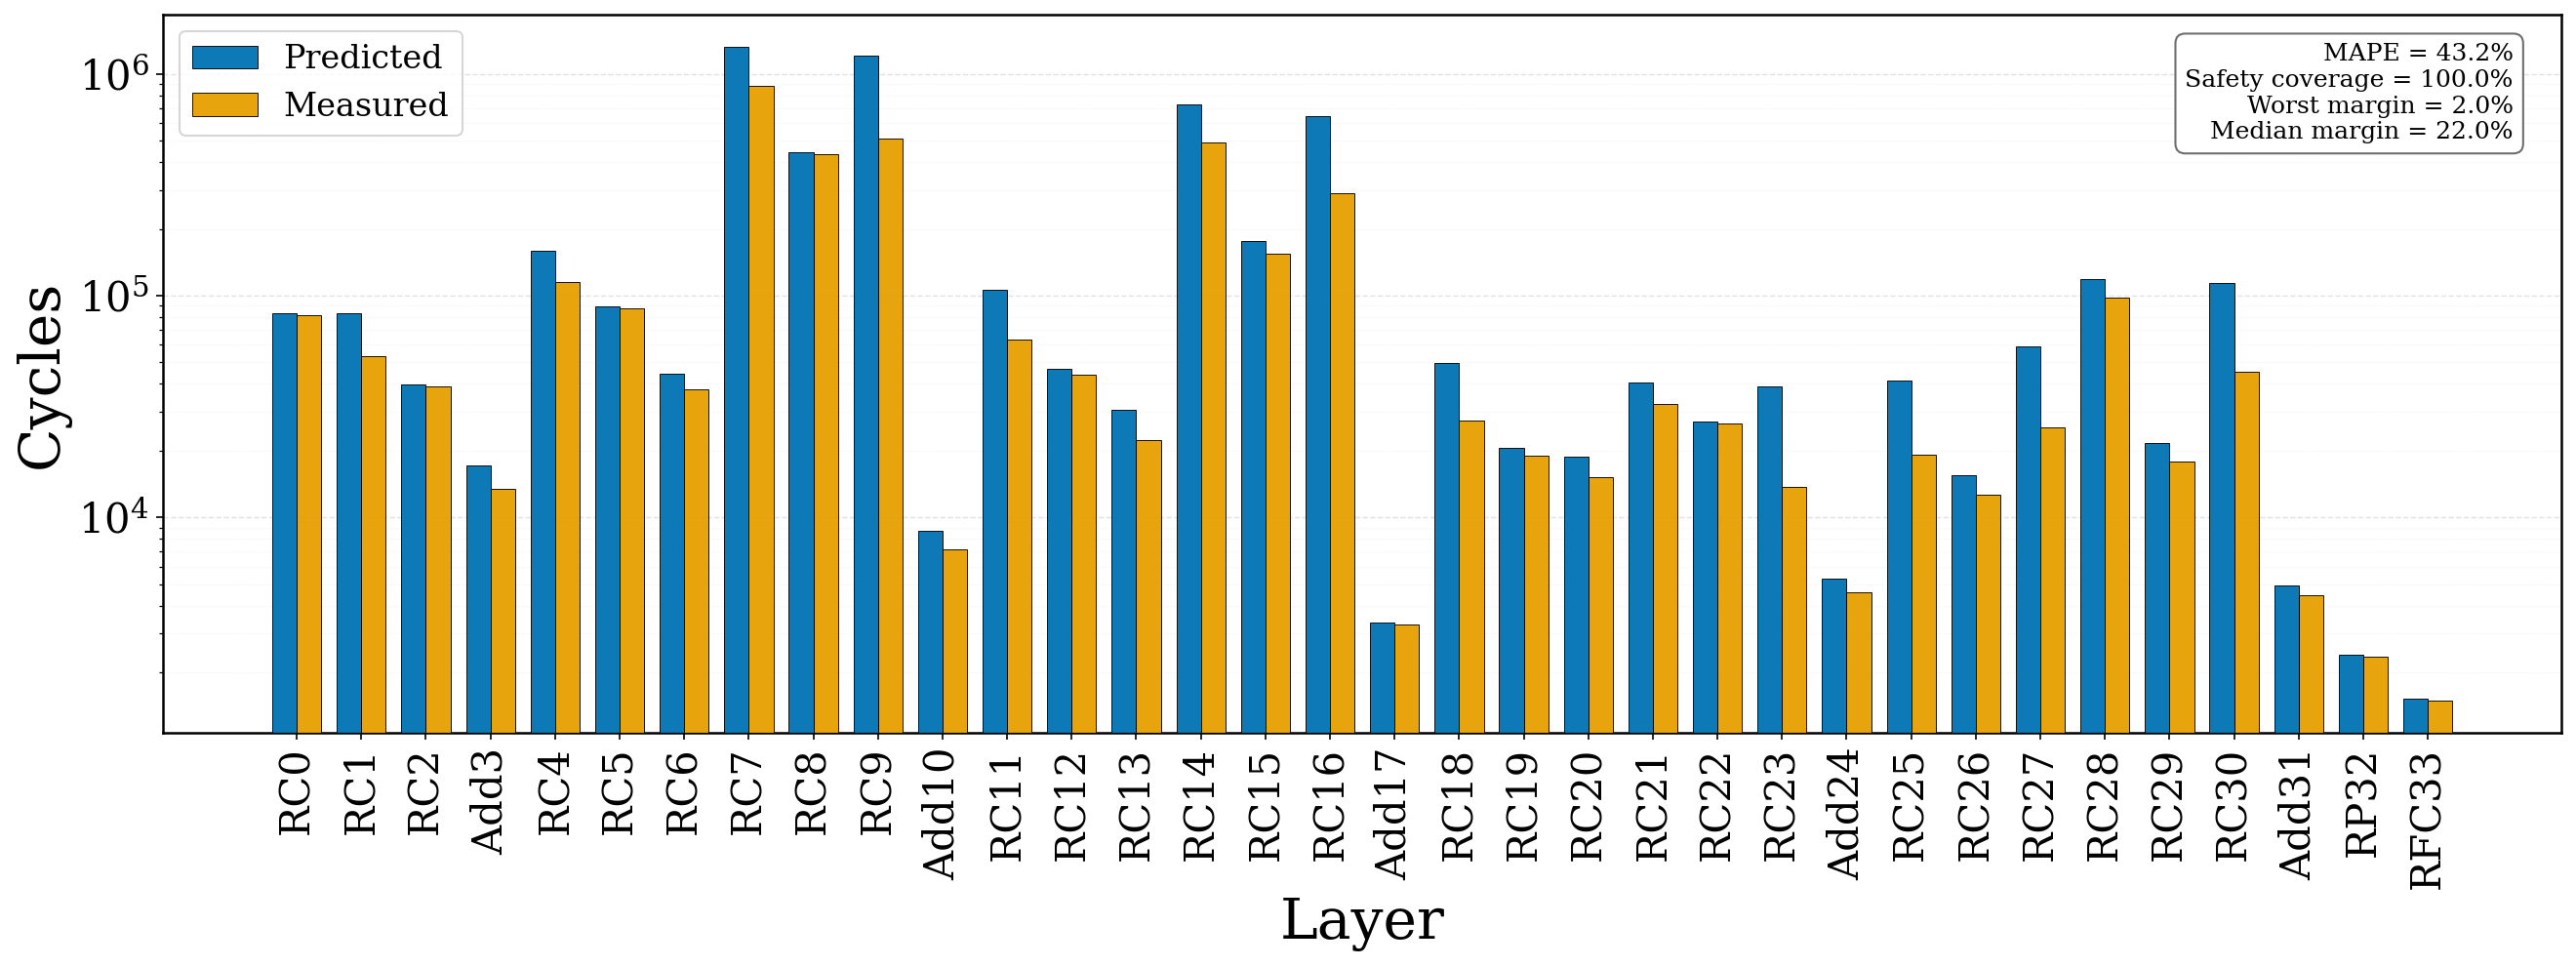

In [ ]:
model_name = "efficientnet"
case_number = 1
platform = 1

predicted_latency_path = (
    f"./output/"
    f"STEP2_{model_name}_case {case_number}_"
    f"platform {platform}_latency.csv"
)

measured_latency_path = (
    f"./output/"
    f"STEP3_paltform {platform}_"
    f"{model_name}_case {case_number}.csv"
)

comparison, metrics = plot_latency_validation(
    predicted_latency_path=predicted_latency_path,
    measured_latency_path=measured_latency_path,
    model_name=model_name,
    case_number=case_number,
    platform=platform,
    figsize=(18, 7),
    save_path=None,
)